## Plotting and visualization with biotuner

This notebook walks through the biotuner plotting API on rich synthetic signals
that produce well-populated, "garnished" figures. We cover single-series peak
analysis, tuning visualization, harmonic-fit diagnostics, multi-channel
dissonance curves, and group-level plots on a `BiotunerGroup`.

#### Table of contents

1. [Setup and synthetic signals](#1-setup-and-synthetic-signals)
2. [Peak analysis plots](#2-peak-analysis-plots)
3. [Tuning visualization](#3-tuning-visualization)
4. [Harmonic-fit diagnostics](#4-harmonic-fit-diagnostics)
5. [Multi-channel dissonance curve](#5-multi-channel-dissonance-curve)
6. [Group analysis plots (BiotunerGroup)](#6-group-analysis-plots)
7. [3D group heatmaps (trials × channels)](#7-3d-group-heatmaps)

### 1. Setup and synthetic signals

We build three synthetic signals chosen to highlight different aspects of
the plotting API:

- **Signal A — harmonic stack.** A clean fundamental at 5 Hz with octave and
  inner harmonics (5, 10, 15, 20, 25, 30, 40 Hz). Yields tight ratios and rich
  dissonance curves.
- **Signal B — just-intonation chord.** A 4:5:6:7:8:10 chord centered around
  6 Hz. Highlights septimal intervals.
- **Signal C — EEG-like multi-band.** Theta + alpha + beta + gamma with
  realistic noise. Produces a busier spectrum and broader peak distribution.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from biotuner.biotuner_object import compute_biotuner
from biotuner.biotuner_group import BiotunerGroup
from biotuner.plot_config import set_biotuner_style
from biotuner.vizs import diss_curve_multi

set_biotuner_style()

rng = np.random.default_rng(7)
sf = 1000
duration = 8
t = np.linspace(0, duration, sf * duration, endpoint=False)


def make_signal(freqs, amps, noise=0.05):
    sig = sum(a * np.sin(2 * np.pi * f * t) for f, a in zip(freqs, amps))
    return sig + noise * rng.standard_normal(len(t))


# A — dense harmonic stack
sig_A = make_signal(
    [5, 10, 15, 20, 25, 30, 40],
    [1.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.2],
    noise=0.05,
)

# B — just-intonation chord (4:5:6:7:8:10) on a 6 Hz base
base = 6
sig_B = make_signal(
    [base * r for r in (1, 5/4, 6/4, 7/4, 8/4, 10/4)],
    [1.0, 0.85, 0.75, 0.6, 0.5, 0.4],
    noise=0.06,
)

# C — EEG-like
sig_C = make_signal(
    [6, 10, 12, 22, 30, 45],
    [0.8, 1.0, 0.7, 0.5, 0.4, 0.3],
    noise=0.25,
)

print(f"sig_A: {sig_A.shape}, sig_B: {sig_B.shape}, sig_C: {sig_C.shape}")

sig_A: (8000,), sig_B: (8000,), sig_C: (8000,)


We instantiate three `compute_biotuner` objects, extract peaks, compute
metrics, and pre-compute the dissonance and harmonic-entropy curves so every
downstream plot has its data ready.

In [5]:
def build_bt(signal, label, peaks_function="harmonic_recurrence",
             min_freq=2, max_freq=50, n_peaks=7):
    bt = compute_biotuner(
        sf=sf,
        peaks_function=peaks_function,
        precision=0.25,
        n_harm=10,
    )
    bt.peaks_extraction(
        signal,
        min_freq=min_freq,
        max_freq=max_freq,
        n_peaks=n_peaks,
        min_harms=2,
        ratios_extension=True,
        graph=False,
    )
    bt.compute_peaks_metrics()
    # extend peaks so the dissonance curve is densely populated
    bt.peaks_extension(method="harmonic_fit", n_harm=10,
                       cons_limit=0.1, ratios_extension=False)
    bt.compute_diss_curve(input_type="extended_peaks",
                          denom=100, max_ratio=2,)
    print(f"{label:>22s}  peaks = {np.round(bt.peaks, 2)}")
    return bt


bt_A = build_bt(sig_A, "A — harmonic stack")
bt_B = build_bt(sig_B, "B — JI chord")
bt_C = build_bt(sig_C, "C — EEG-like")

    A — harmonic stack  peaks = [ 2.5   5.    3.   10.   15.    8.25 20.  ]
          B — JI chord  peaks = [ 3.75  2.75  7.5   6.    9.   10.5  16.5 ]
          C — EEG-like  peaks = [ 3.5   6.   12.   10.   30.   18.25 15.  ]


### 2. Peak analysis plots

`plot_peaks(show_matrix=True)` returns a 3-panel figure: power-spectrum
with peak markers, peak amplitudes (with note labels), and the peak harmonicity
matrix. This is the most informative single view of a biotuner object.

C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:1138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


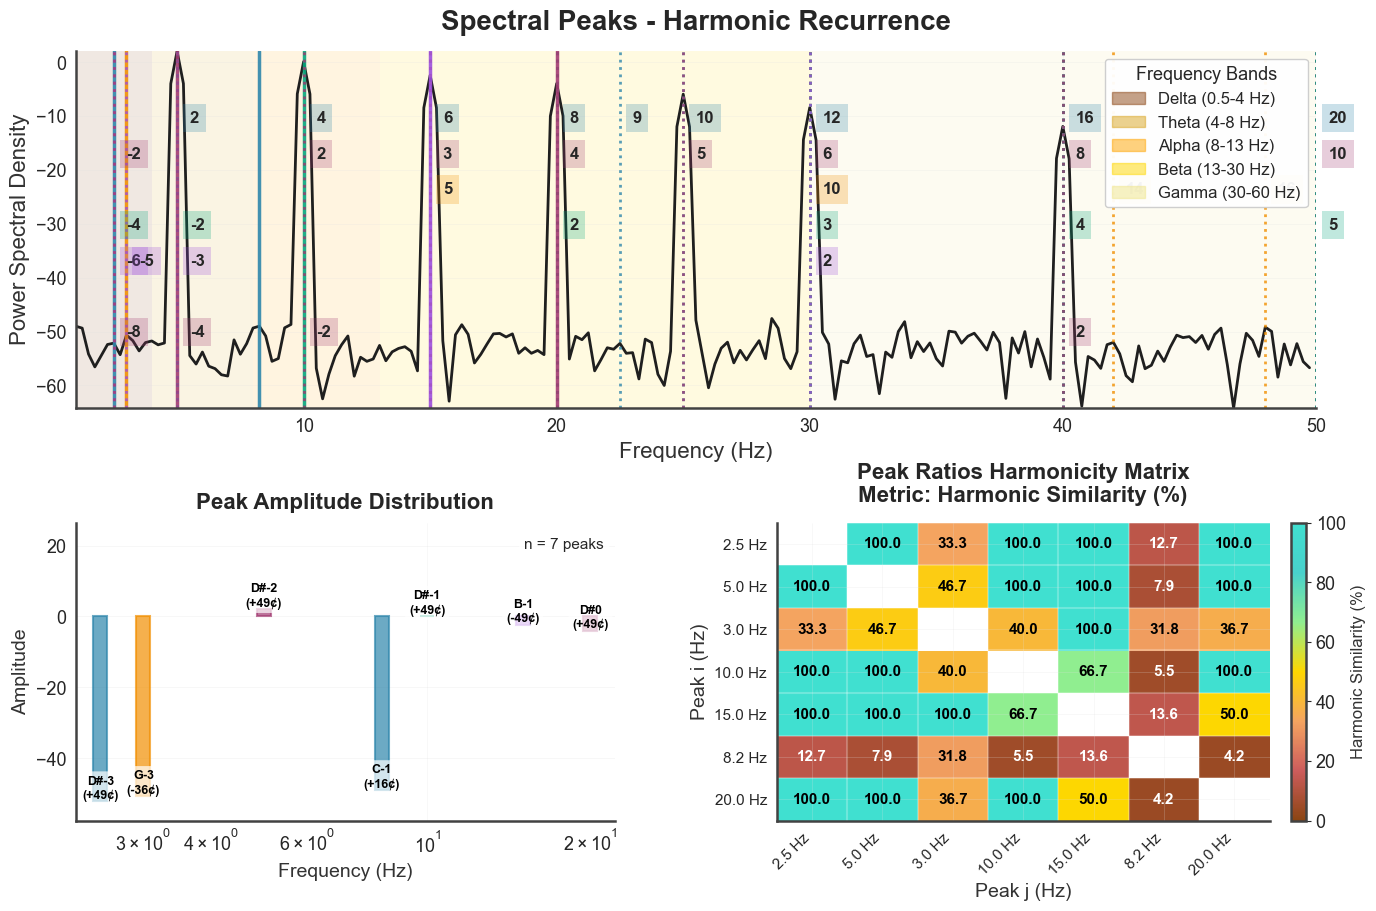

In [6]:
bt_A.plot_peaks(xmin=1, xmax=50, show_matrix=True)
plt.show()

Same plot for the JI chord and the EEG-like signal:

C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:1138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


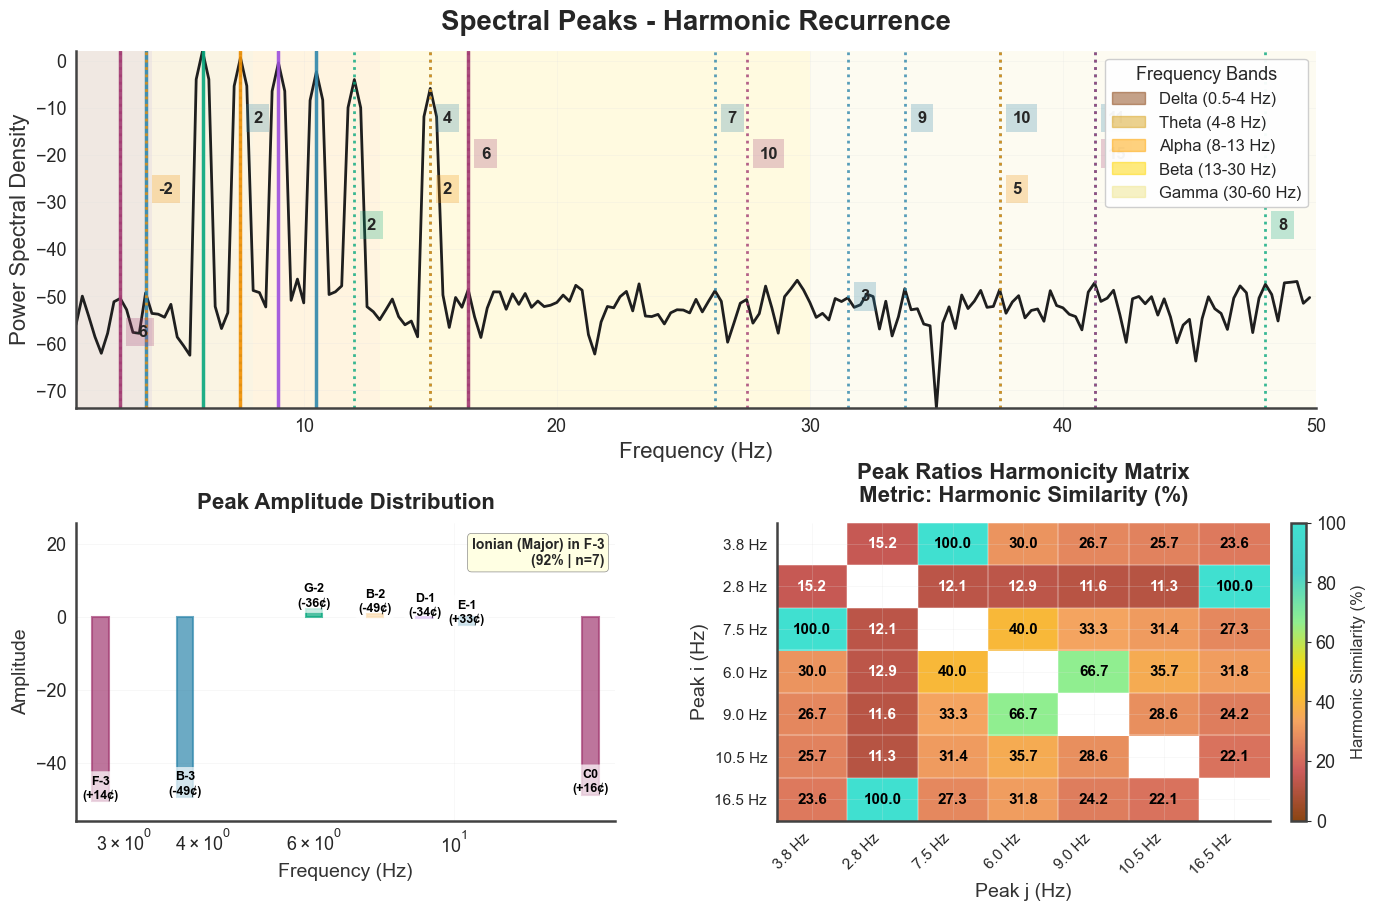

In [7]:
bt_B.plot_peaks(xmin=1, xmax=50, show_matrix=True)
plt.show()

C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:1138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


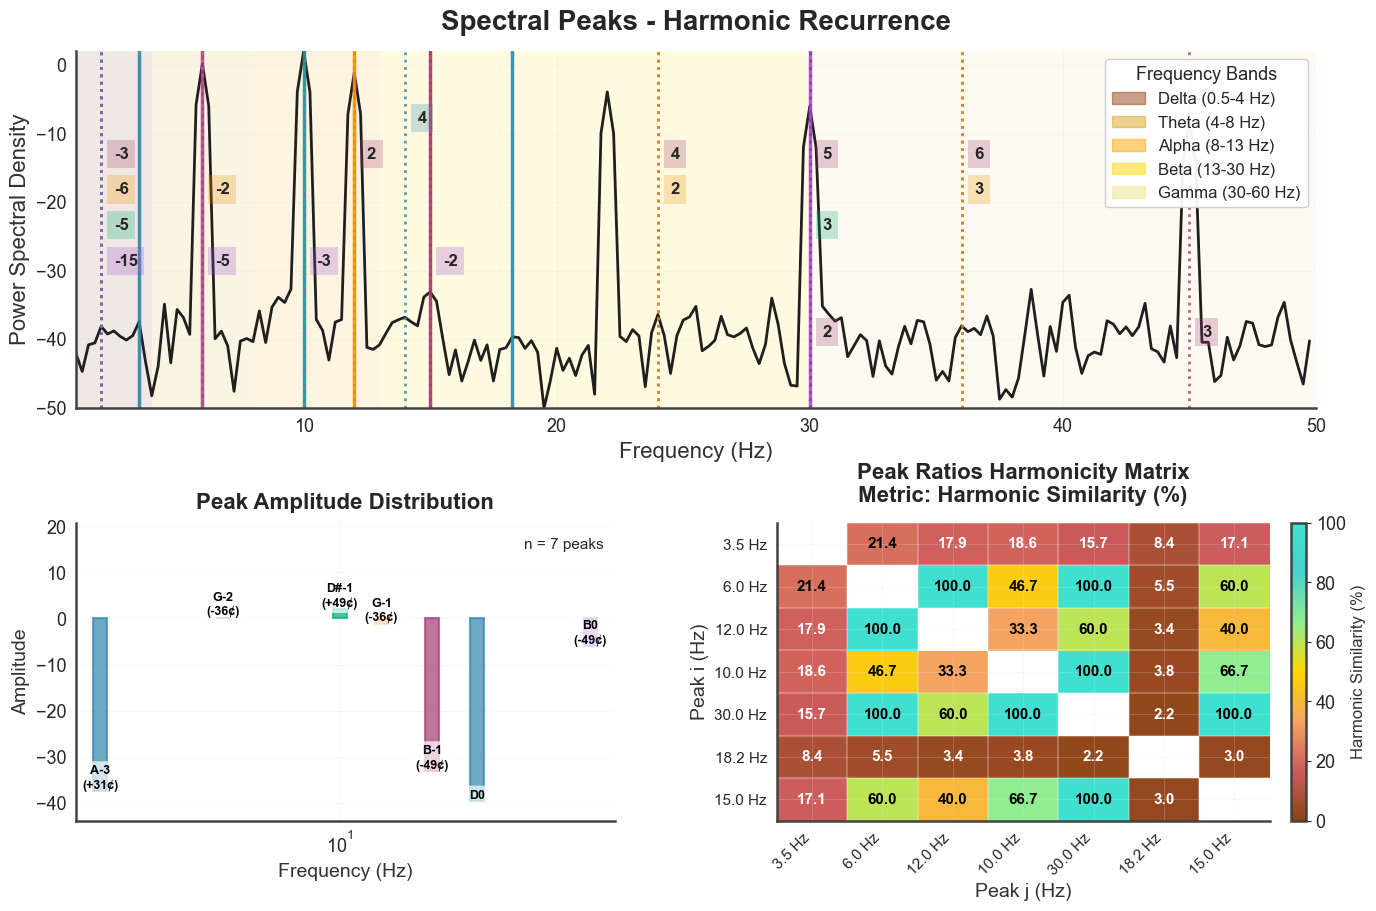

In [8]:
bt_C.plot_peaks(xmin=1, xmax=50, show_matrix=True)
plt.show()

The individual panels are also exposed as standalone methods, useful for
embedding a single panel in a custom layout.

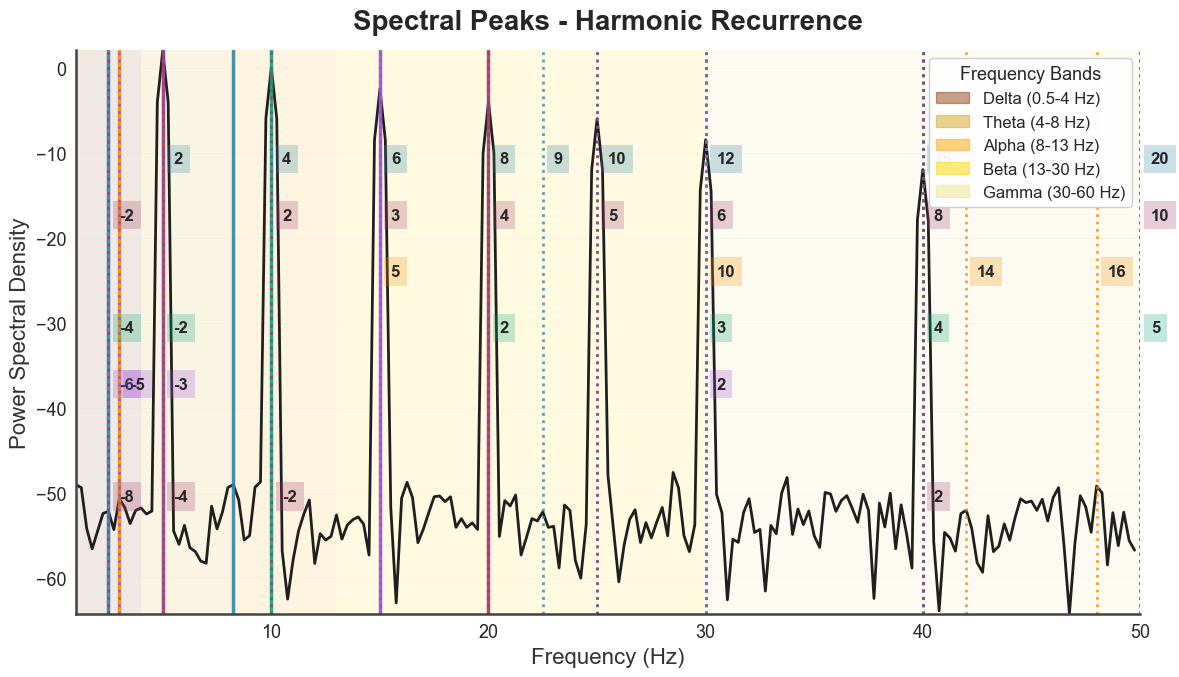

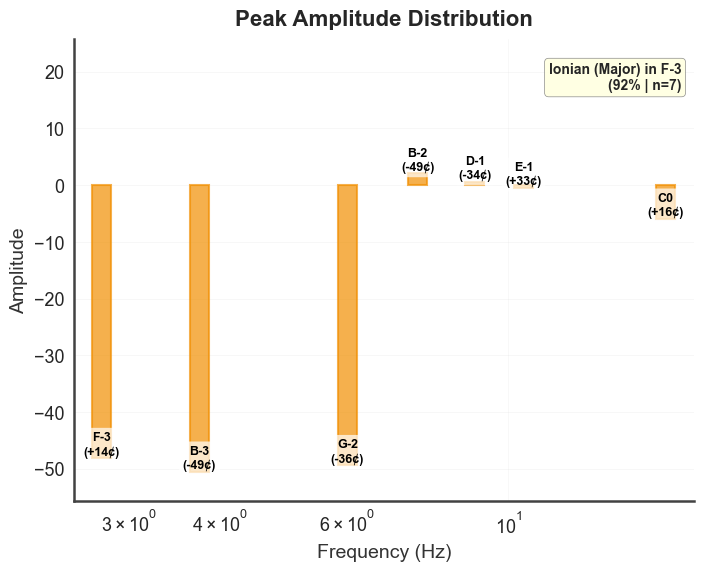

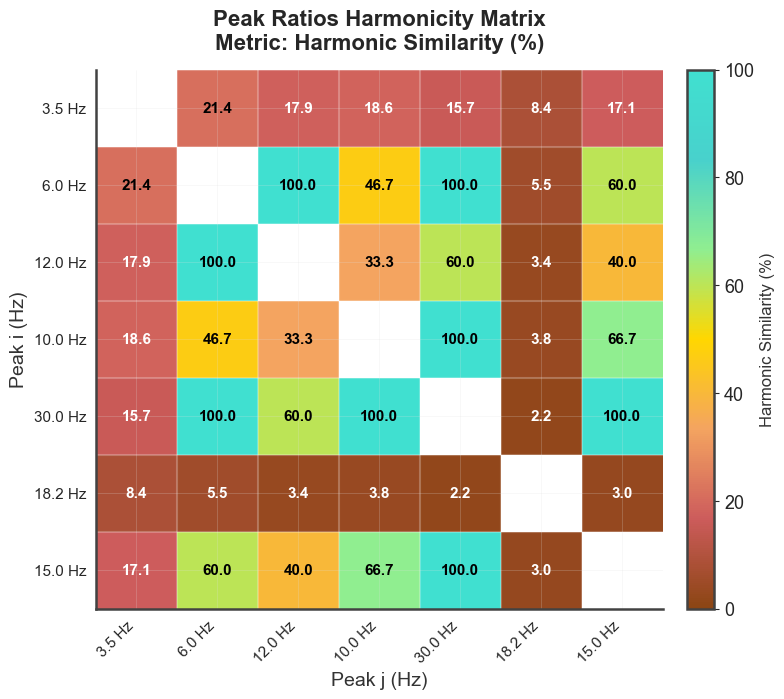

In [9]:
# spectrum-only view
bt_A.plot_peaks_spectrum(xmin=1, xmax=50)
plt.show()

# amplitude bars with musical-note labels
bt_B.plot_peaks_amplitude(xmin=1, xmax=50)
plt.show()

# harmonicity matrix between peak pairs
bt_C.plot_peaks_matrix(metric="harmsim")
plt.show()

### 3. Tuning visualization

`plot_tuning()` is the workhorse for scale visualization. With
`panels=4, show_source_curve=True` it produces a four-panel summary: source
curve at the top, then scale steps, consonance matrix, and step-size intervals.
The `tuning` argument selects which scale to display
(`peaks_ratios`, `diss_curve`, `harm_tuning`, `harm_fit_tuning`,
`euler_fokker`, `HE`).

C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:2348: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:2497: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:2571: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:2724: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


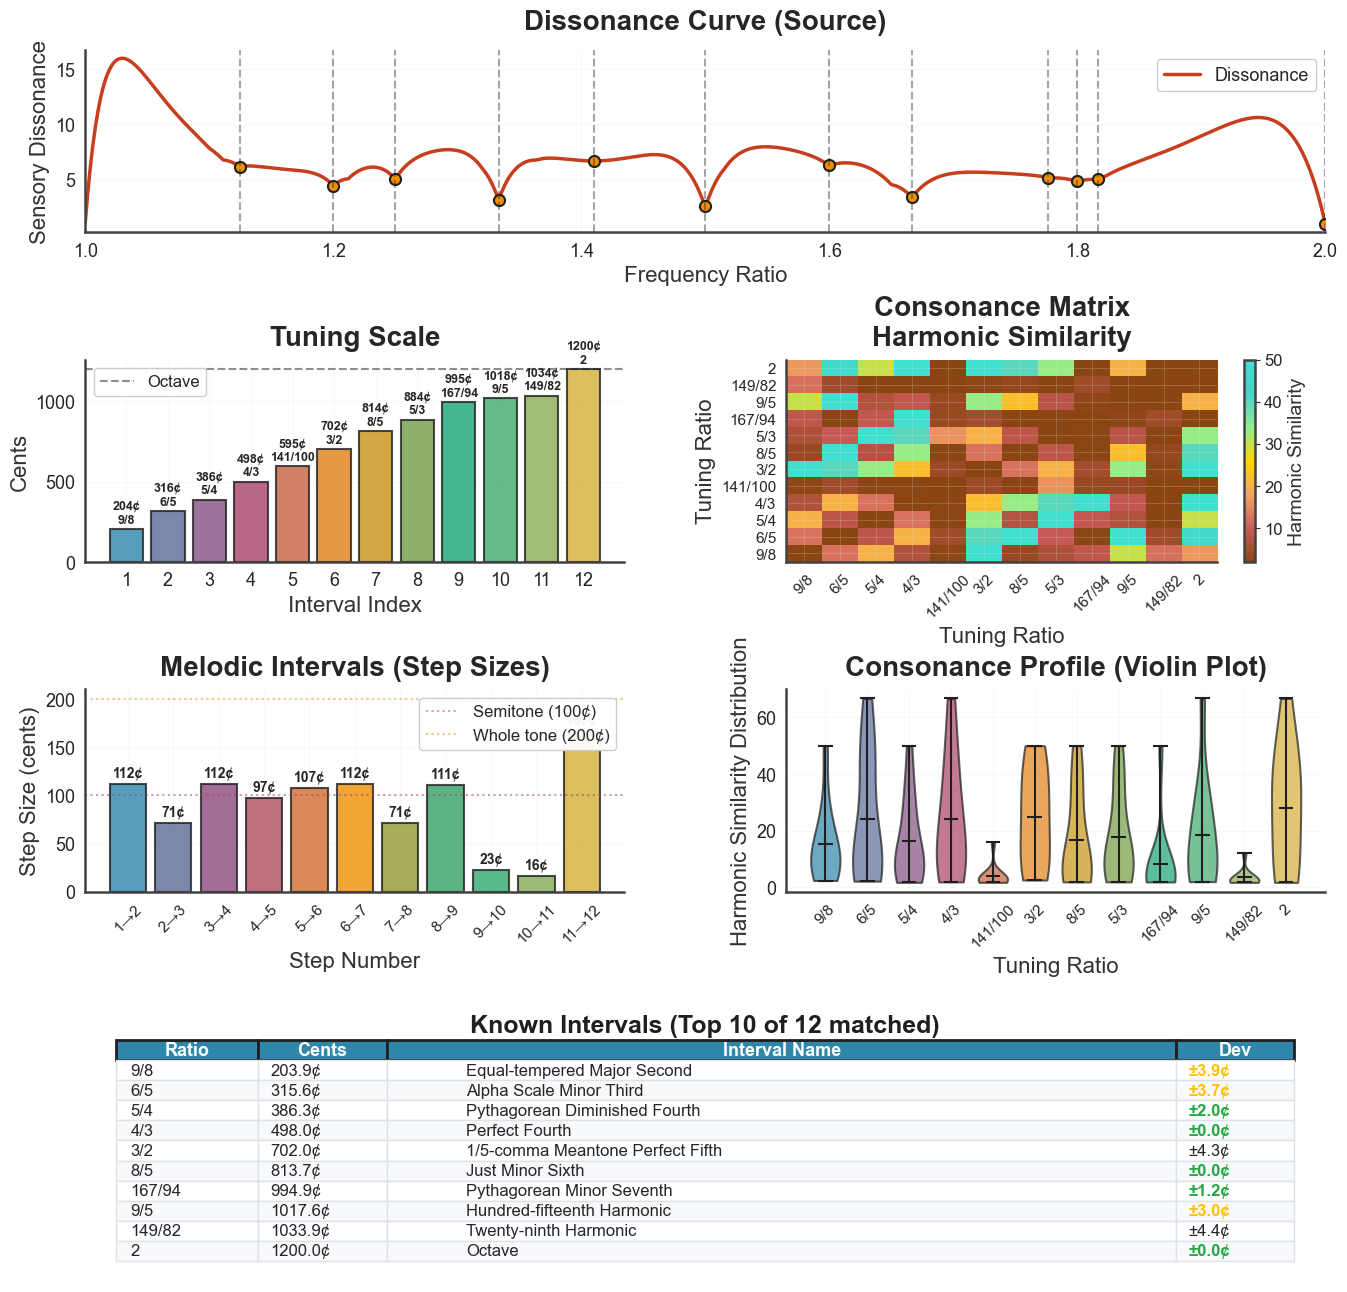

In [10]:
bt_A.plot_tuning(tuning="diss_curve", metric="harmsim",
                 panels=4, show_source_curve=True)
plt.show()

C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:2348: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:2497: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:2571: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:2724: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


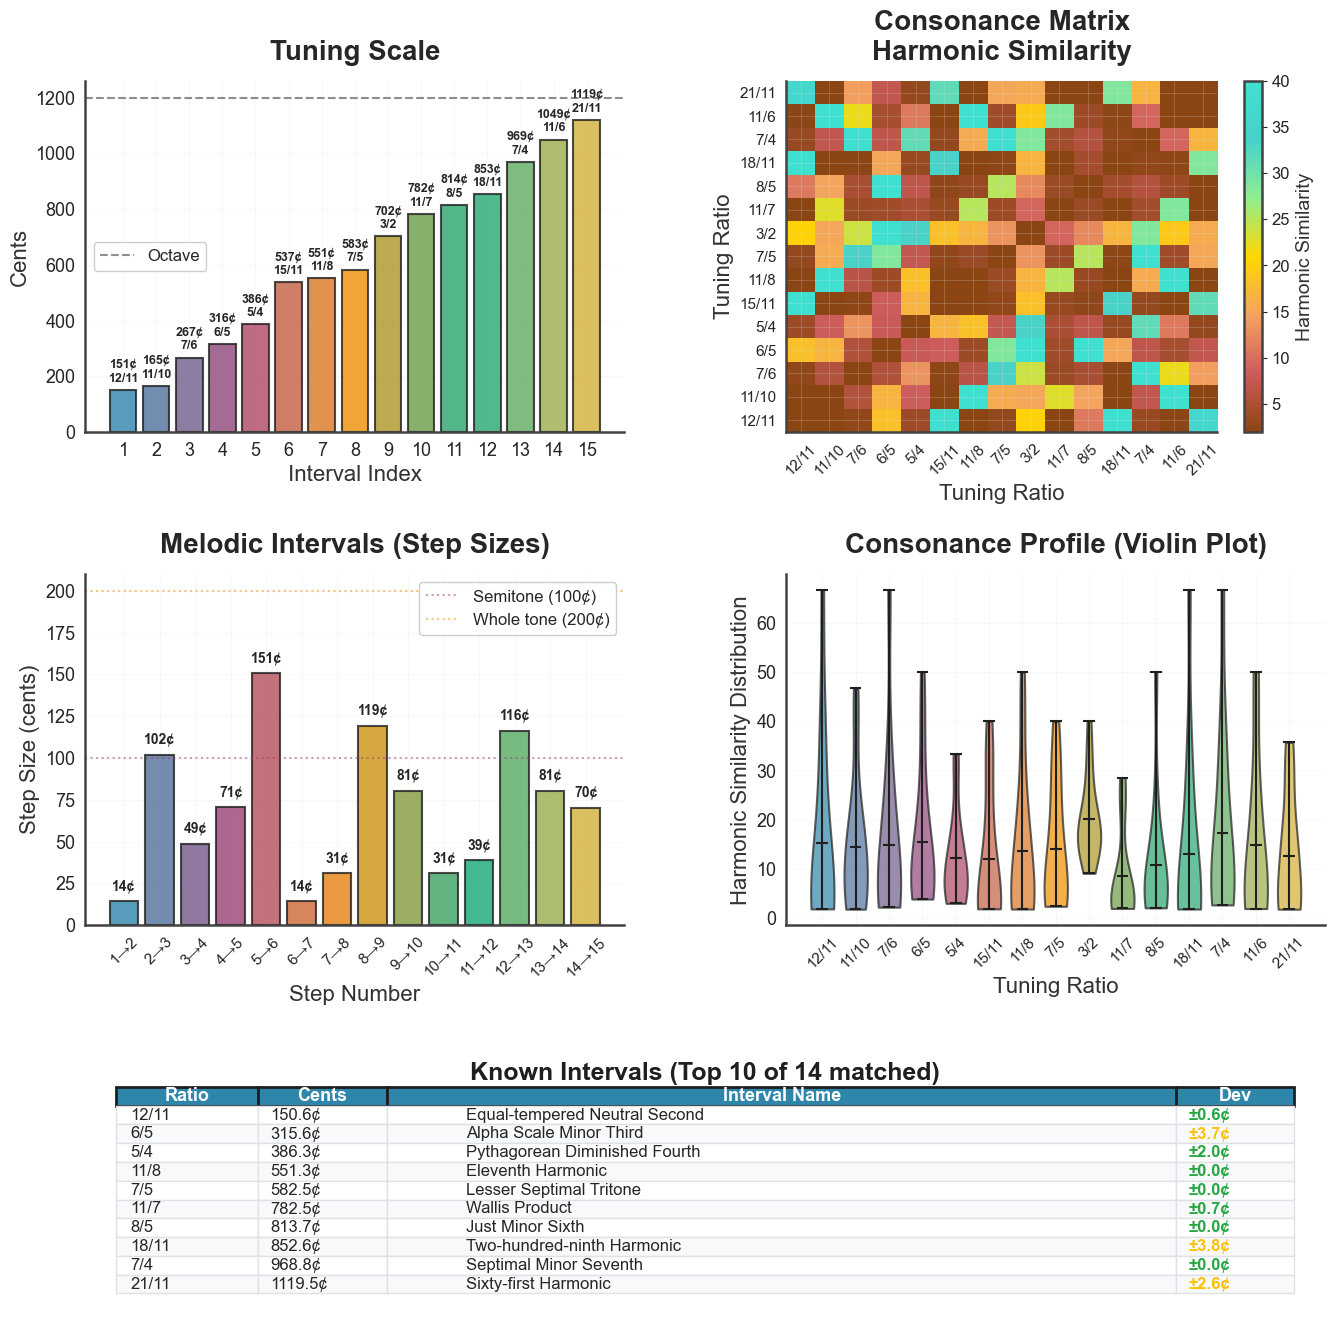

In [11]:
bt_B.plot_tuning(tuning="peaks_ratios", metric="harmsim",
                 panels=4, show_source_curve=True)
plt.show()

Each panel is also available individually:

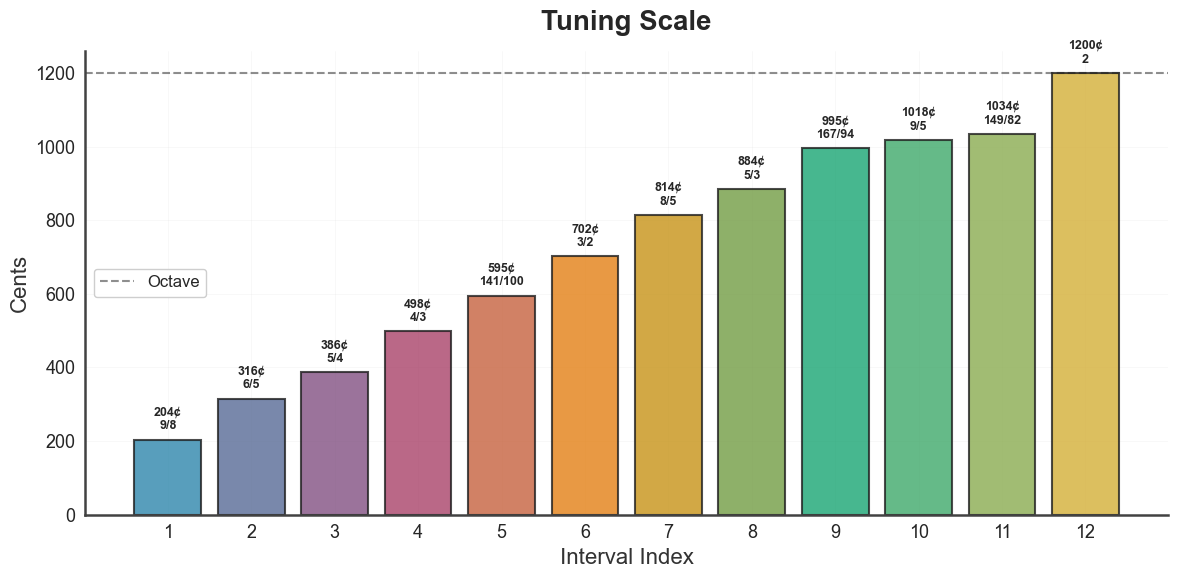

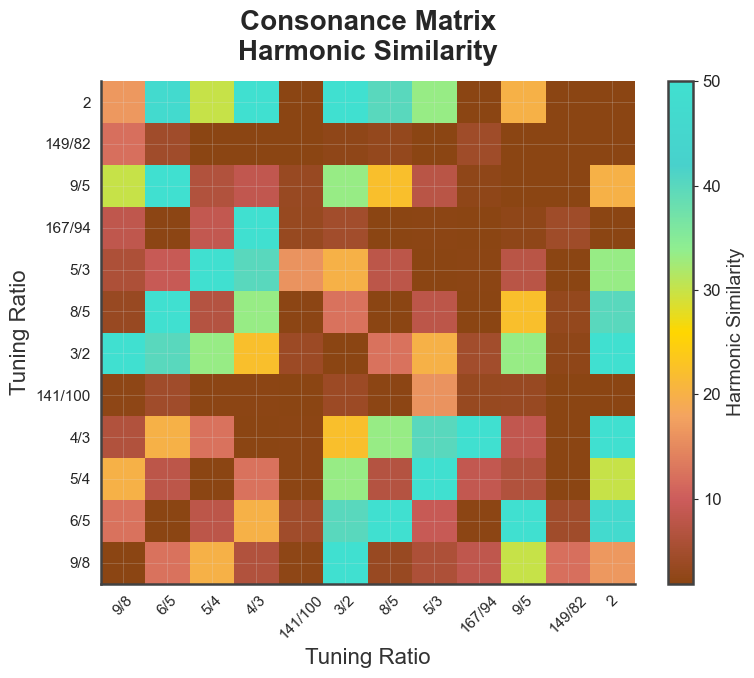

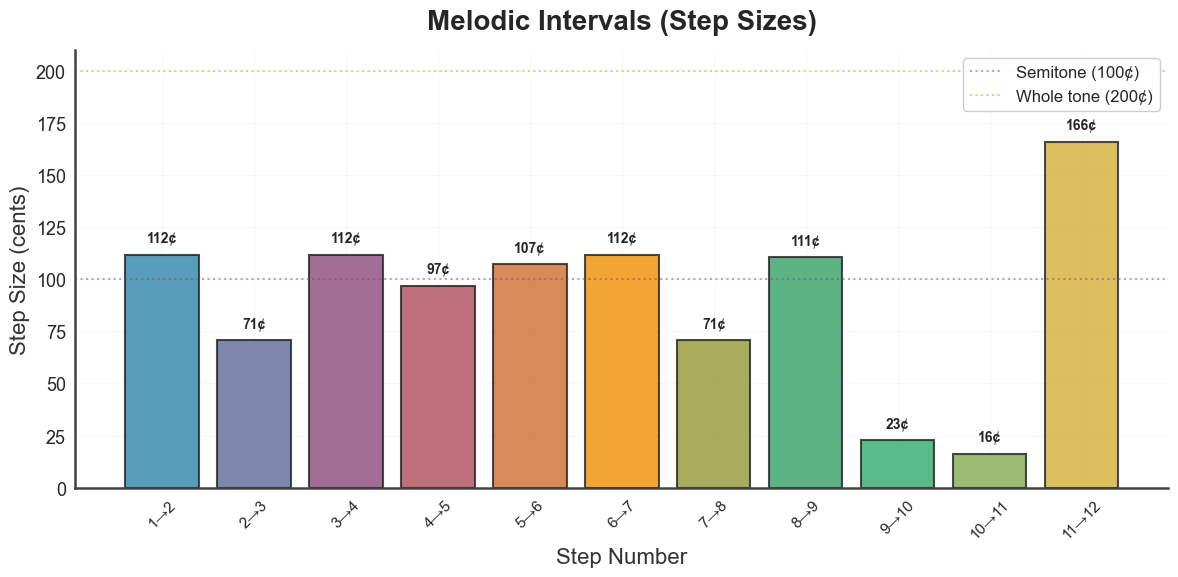

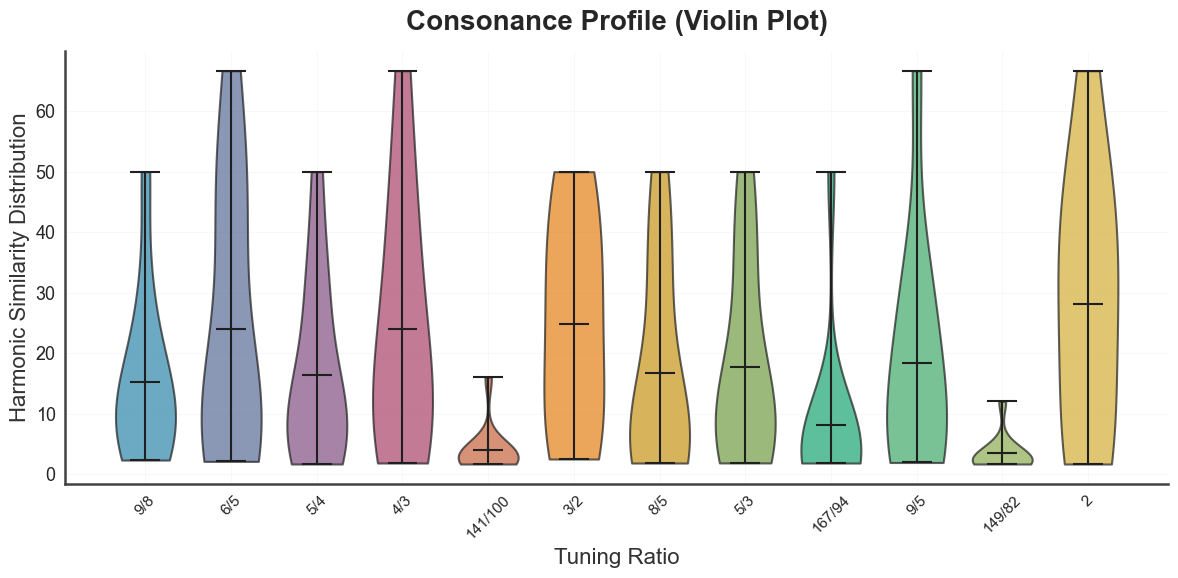

In [12]:
bt_A.plot_tuning_scale(tuning="diss_curve")
plt.show()

bt_A.plot_tuning_matrix(tuning="diss_curve", metric="harmsim")
plt.show()

bt_A.plot_tuning_intervals(tuning="diss_curve")
plt.show()

bt_A.plot_tuning_consonance_profile(tuning="diss_curve", metric="harmsim")
plt.show()

`plot_tuning_curve` renders the underlying source curve (dissonance or
harmonic entropy) with detected minima highlighted.

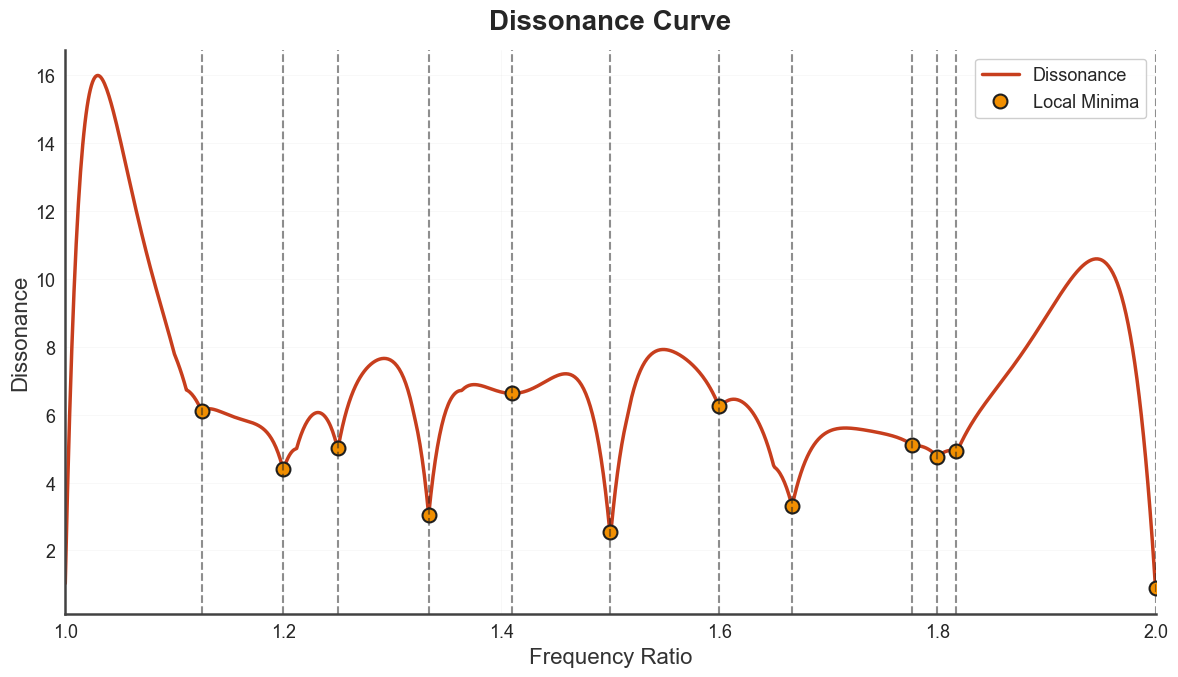

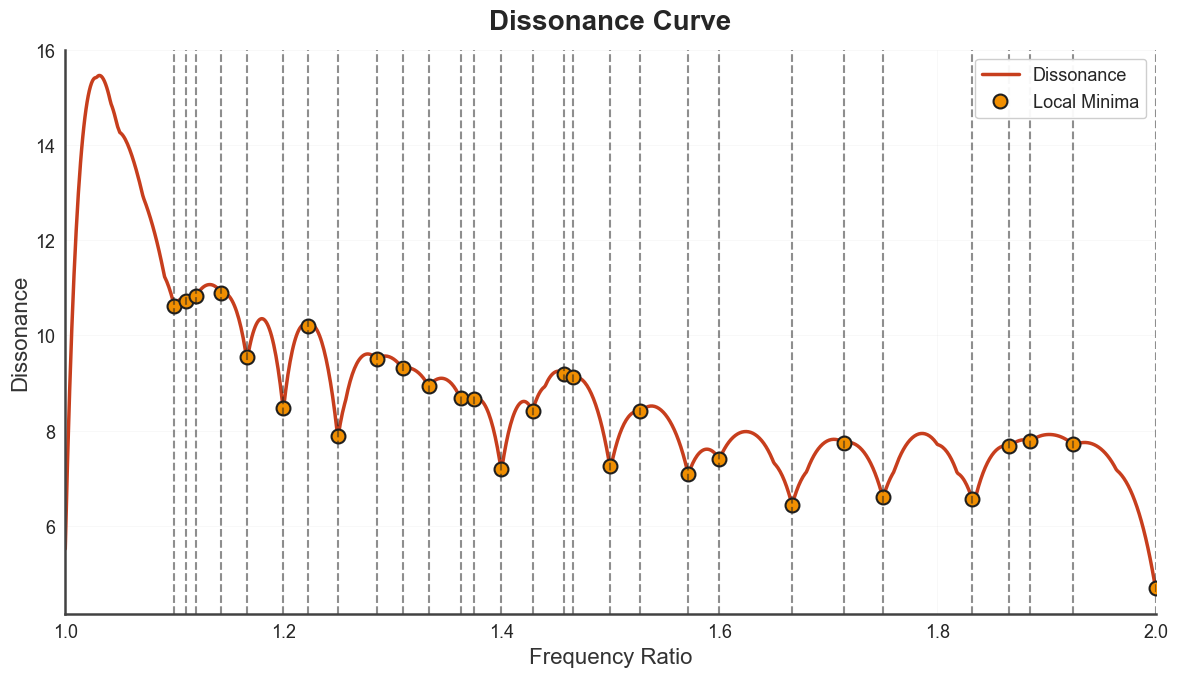

In [13]:
bt_A.plot_tuning_curve(curve_type="dissonance")
plt.show()

bt_B.plot_tuning_curve(curve_type="dissonance")
plt.show()

`plot_tuning_interval_table` annotates each scale step with the closest
named just-intonation interval, within a tolerance you set.

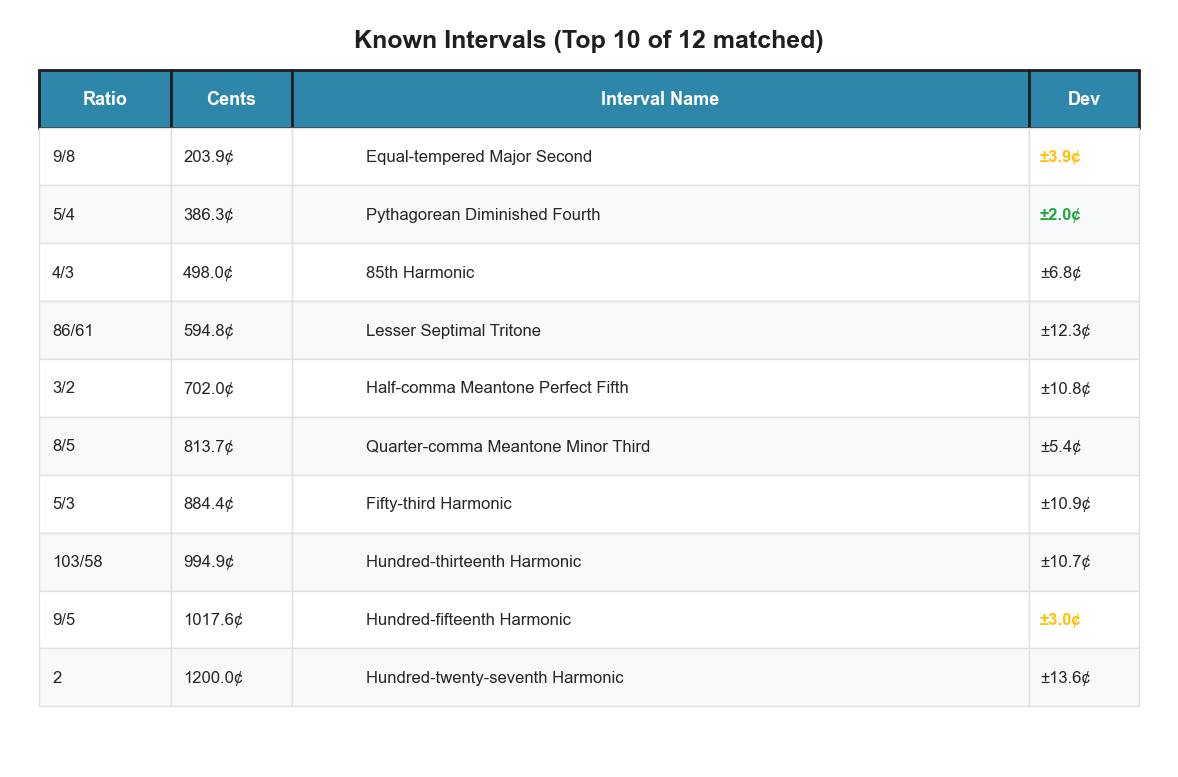

In [14]:
bt_A.plot_tuning_interval_table(tuning="diss_curve",
                                max_denom=64, tolerance_cents=15)
plt.show()

### 4. Harmonic-fit diagnostics

`plot_harmonic_fit()` produces a 2×2 panel showing how well the spectral
peaks fit a shared harmonic series. Top-left: PSD with peak markers and
extension positions; top-right: harmonic positions per peak; bottom-left:
harmonic-fit network (which harmonic of which peak coincides with which other
peak); bottom-right: connectivity matrix.

C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:3884: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:3990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:4221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:4366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
c:\Users\skite\miniconda3\envs\biotuner_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Ari

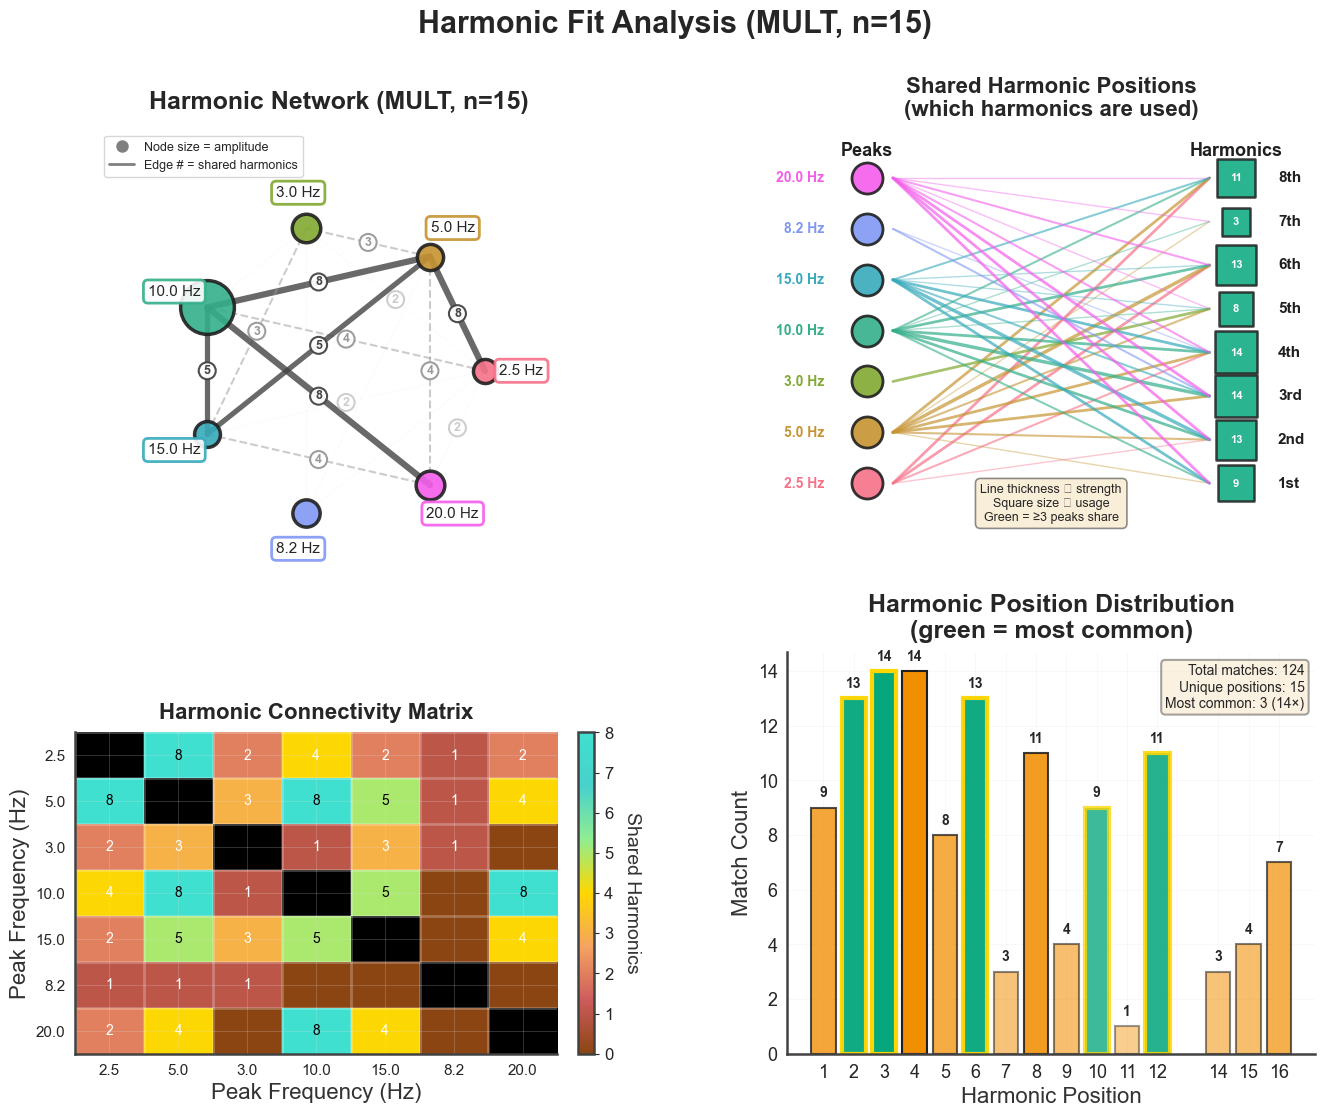

In [15]:
bt_A.plot_harmonic_fit(n_harm=15, harm_bounds=0.5)
plt.show()

C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:3884: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:3990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:4221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:4366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
c:\Users\skite\miniconda3\envs\biotuner_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Ari

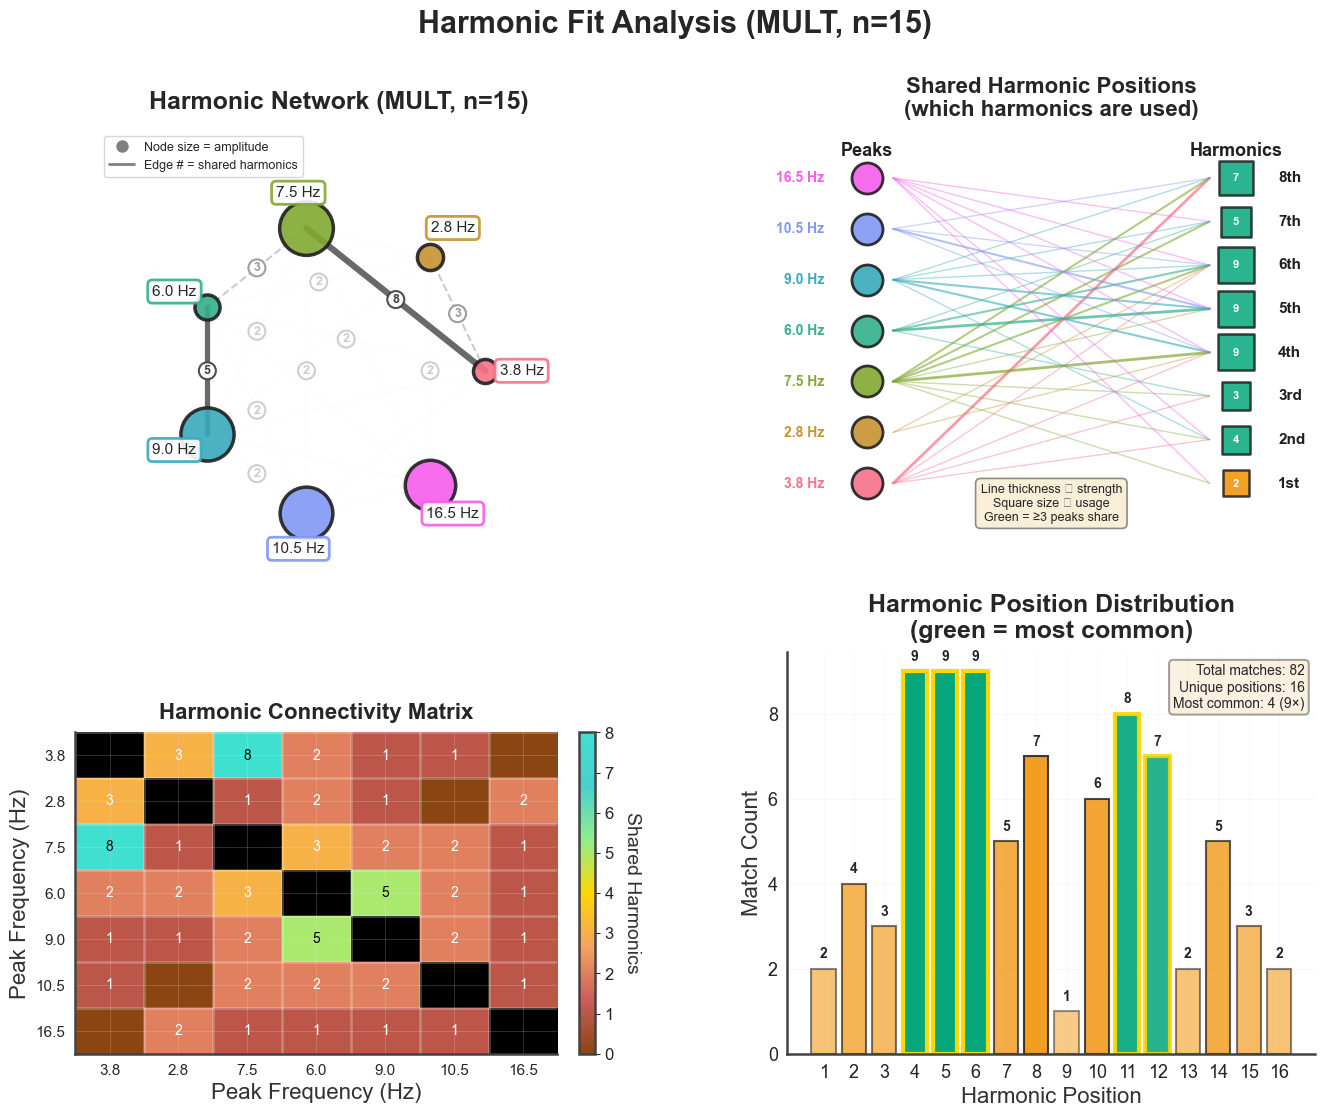

In [16]:
bt_B.plot_harmonic_fit(n_harm=15, harm_bounds=0.5)
plt.show()

Each subview is exposed as its own method:

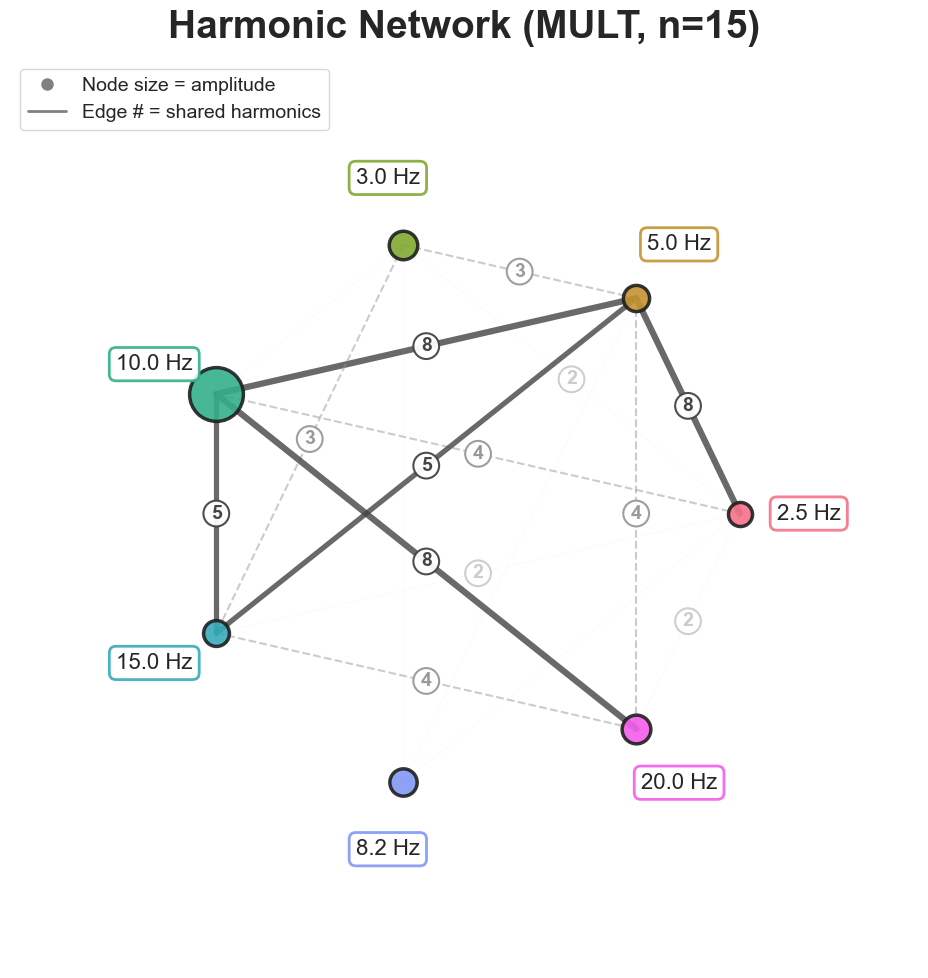

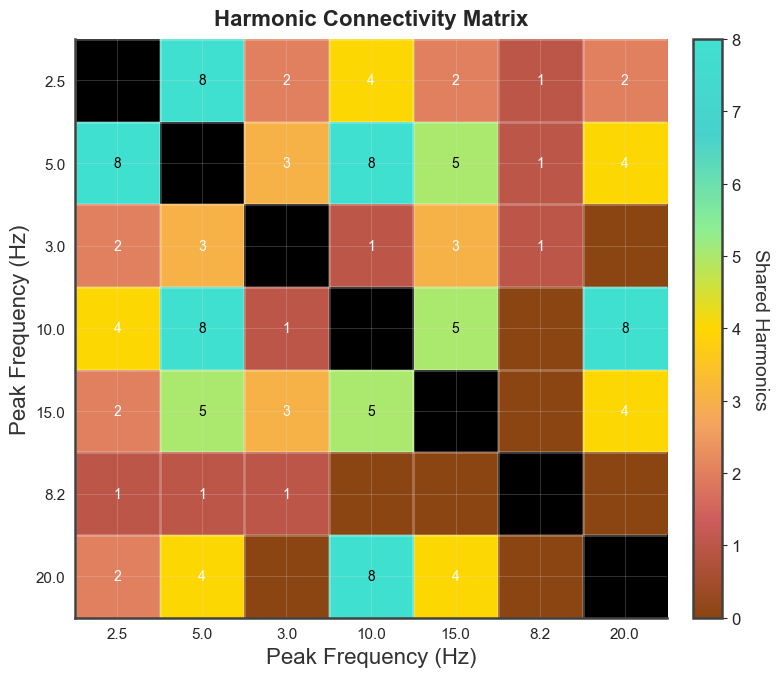

C:\Users\skite\Documents\Github\biotuner\biotuner\plot_utils.py:4221: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\skite\miniconda3\envs\biotuner_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


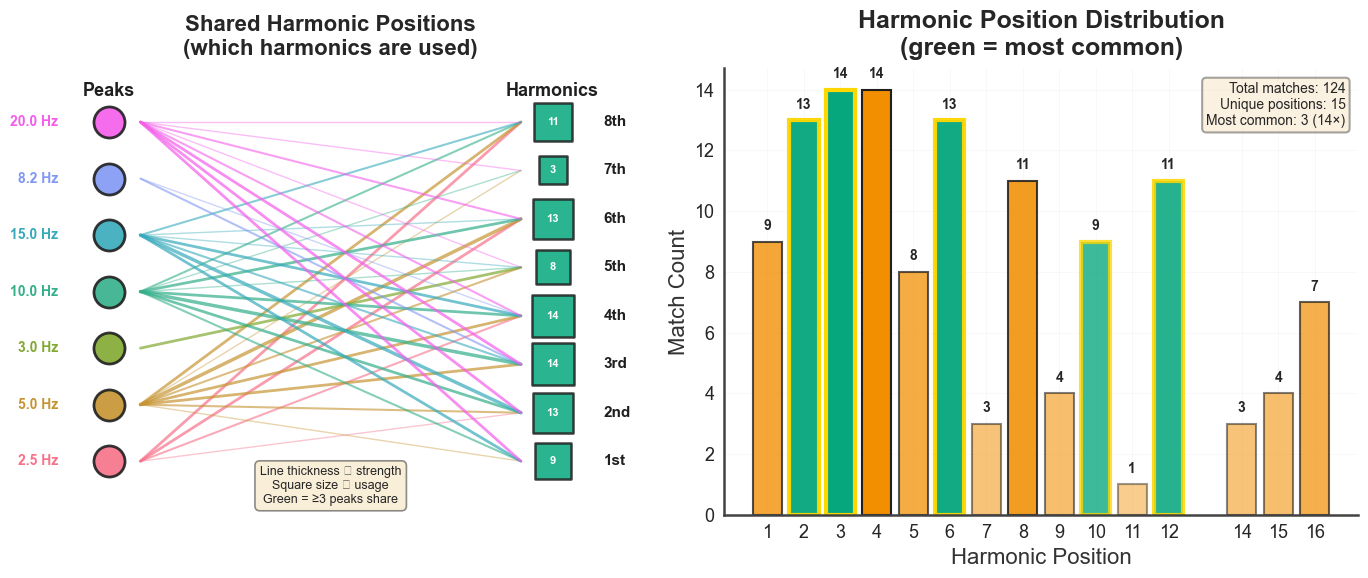

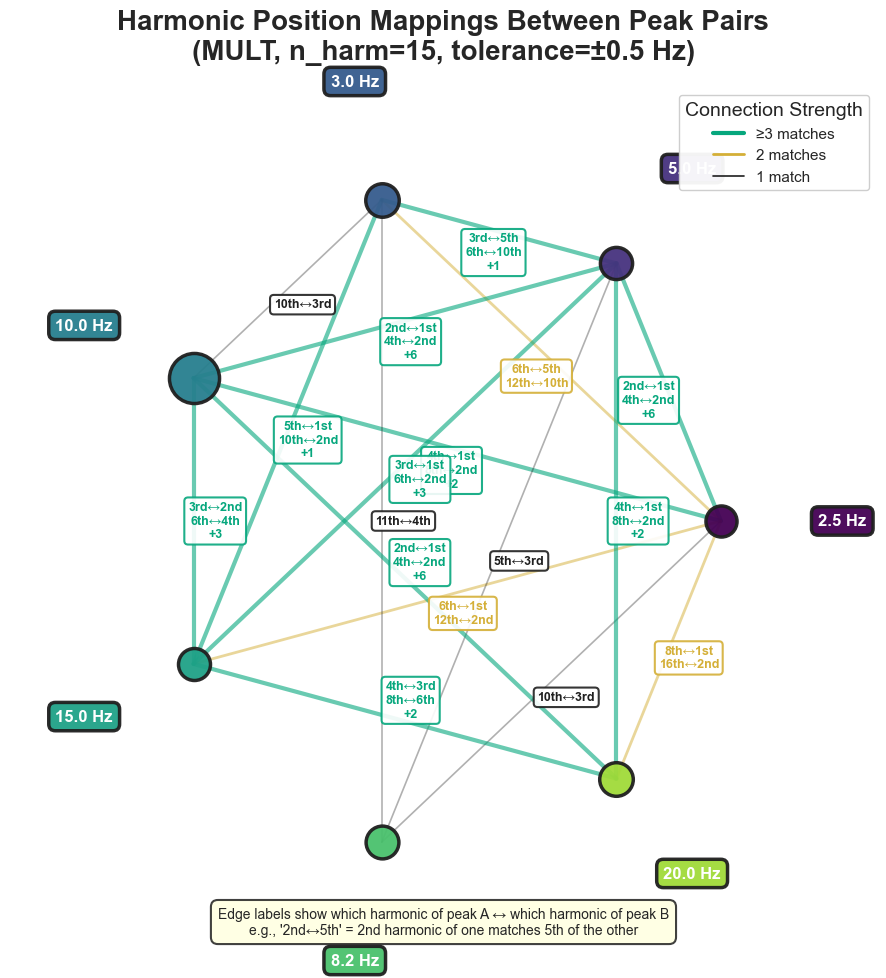

In [17]:
bt_A.plot_harmonic_fit_network(n_harm=15, harm_bounds=0.5)
plt.show()

bt_A.plot_harmonic_fit_matrix(n_harm=15, harm_bounds=0.5)
plt.show()

bt_A.plot_harmonic_fit_positions(n_harm=15, harm_bounds=0.5)
plt.show()

bt_A.plot_harmonic_position_mappings(n_harm=15)
plt.show()

### 5. Multi-channel dissonance curve

`diss_curve_multi` overlays dissonance curves from multiple sources on a
single axis and marks shared minima — useful when looking for tunings that are
consistent across channels or trials.

<Figure size 1600x700 with 0 Axes>

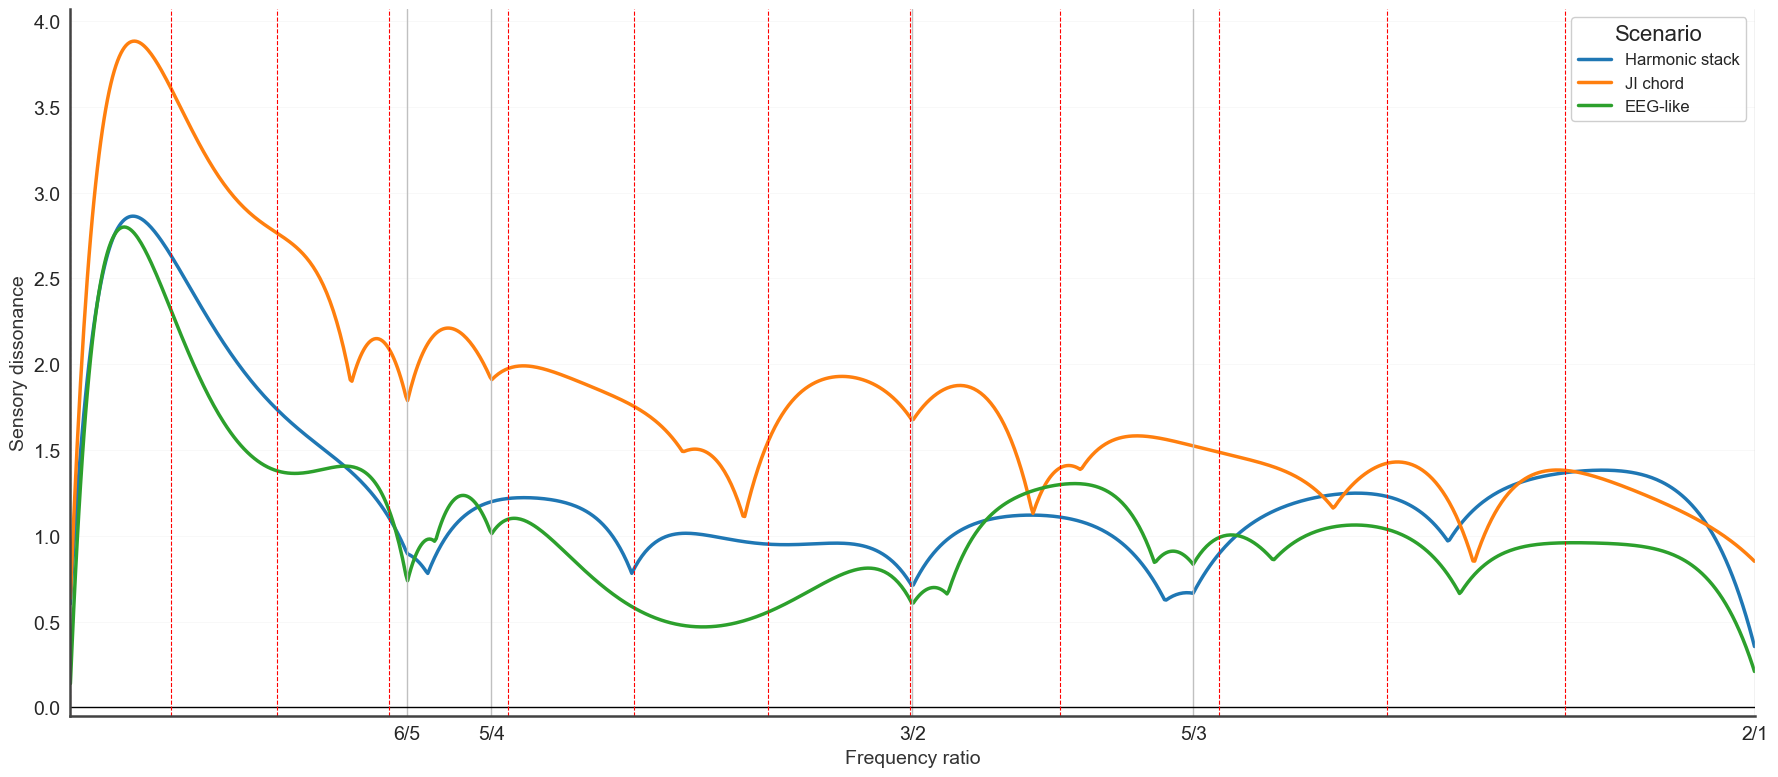

In [18]:
freqs_list = [bt_A.peaks, bt_B.peaks, bt_C.peaks]
amps_list  = [bt_A.amps,  bt_B.amps,  bt_C.amps]
labels     = ["Harmonic stack", "JI chord", "EEG-like"]

plt.figure(figsize=(16, 7))
diss_curve_multi(
    freqs_list, amps_list,
    labels=labels,
    denom=12, max_ratio=2,
    n_tet_grid=12,
    data_type="Scenario",
)
plt.show()

### 6. Group analysis plots

`BiotunerGroup` orchestrates biotuner across many time series and exposes
group-level plots. We build a 24-trial dataset split into two conditions
(harmonic vs inharmonic) so condition-aware plots have something to compare.

In [19]:
N = 12
harmonic_trials = np.array([
    make_signal(
        [5 + rng.uniform(-0.2, 0.2),
         10 + rng.uniform(-0.3, 0.3),
         15 + rng.uniform(-0.3, 0.3),
         20 + rng.uniform(-0.4, 0.4),
         30 + rng.uniform(-0.5, 0.5)],
        [1.0, 0.8, 0.6, 0.5, 0.3], noise=0.1,
    ) for _ in range(N)
])
inharmonic_trials = np.array([
    make_signal(
        [4 + rng.uniform(0, 1.0),
         9 + rng.uniform(0, 1.5),
         13 + rng.uniform(0, 2.0),
         19 + rng.uniform(0, 2.0),
         27 + rng.uniform(0, 2.5)],
        [1.0, 0.7, 0.5, 0.4, 0.3], noise=0.15,
    ) for _ in range(N)
])

group_data = np.vstack([harmonic_trials, inharmonic_trials])  # (24, 8000)
metadata = {"condition": ["harmonic"] * N + ["inharmonic"] * N}
print(f"Group data: {group_data.shape}")

Group data: (24, 8000)


In [21]:
btg = BiotunerGroup(
    group_data, sf=sf,
    axis_labels=["trial"],
    metadata=metadata,
    peaks_function="EMD",
    precision=0.25,
)
btg.compute_peaks(min_freq=2, max_freq=50, n_peaks=6,
                  min_harms=2, verbose=False)
btg.compute_metrics()
btg.compute_diss_curve(input_type="peaks", denom=50, max_ratio=2)
summary = btg.summary()
summary.head()

C:\Users\skite\Documents\Github\biotuner\biotuner\metrics.py:946: RuntimeWarning: divide by zero encountered in scalar divide
  harm_temp.append(1 / delta_norm)


,trial,series_idx,condition,n_peaks,peak_freq_mean,peak_amp_mean,peak_freq_std,peak_amp_std,peak_freq_median,peak_amp_median,...,harm_pos_std,harm_pos_median,harm_pos_min,harm_pos_max,harm_pos_sem,subharm_tension,scale_dissonance,scale_diss_harm_sim,scale_diss_n_steps,common_harm_pos
0,0,0,harmonic,4,9.250000,-6.819295,6.743052,7.603799,7.625,-3.556057,...,3.136877,4.0,1.0,10.0,1.402854,0.024486,0.449587,6.318150,3,NaN
1,1,1,harmonic,4,8.062500,-8.153656,4.874599,10.155705,7.500,-3.625093,...,3.300000,5.5,1.0,11.0,1.043552,0.0,0.510659,26.809599,4,NaN
2,2,2,harmonic,4,13.500000,-10.594103,6.351673,14.275383,14.625,-3.601809,...,2.847696,4.5,1.0,10.0,1.006813,0.010381,0.784228,3.835054,3,1.0
3,3,3,harmonic,3,11.666667,-2.682947,6.371595,1.633655,9.750,-2.450868,...,1.247219,2.0,1.0,4.0,0.720082,0.025528,0.264729,4.796640,3,NaN
4,4,4,harmonic,4,13.875000,-11.281537,6.718677,12.805146,14.875,-4.127662,...,2.680951,3.0,1.0,8.0,1.340476,0.020523,0.794818,9.734093,4,NaN


**Aggregated PSD with individual traces.** `plot_group_peaks` shows the
mean spectrum across trials with per-trial overlays and detected peak
markers.

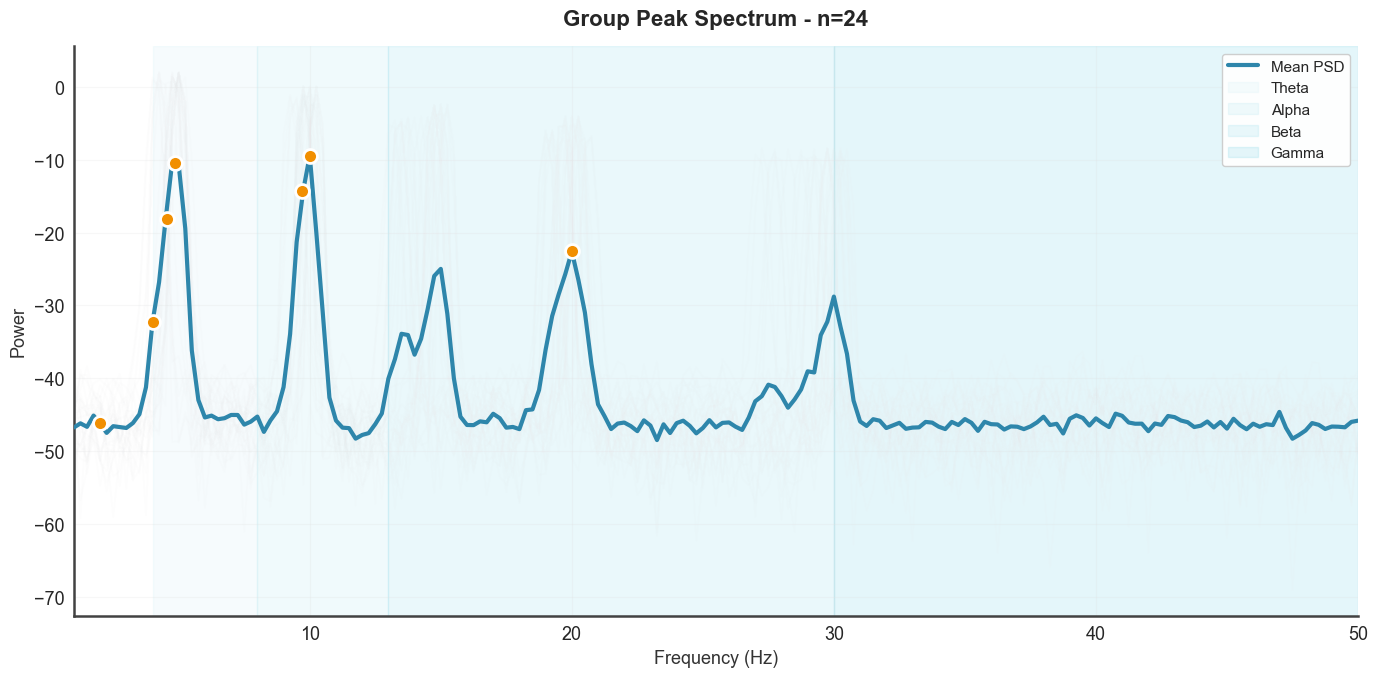

In [22]:
btg.plot_group_peaks(show_individual=True, xmin=1, xmax=50)
plt.show()

**Peak frequency distribution** across all trials, with band shading.

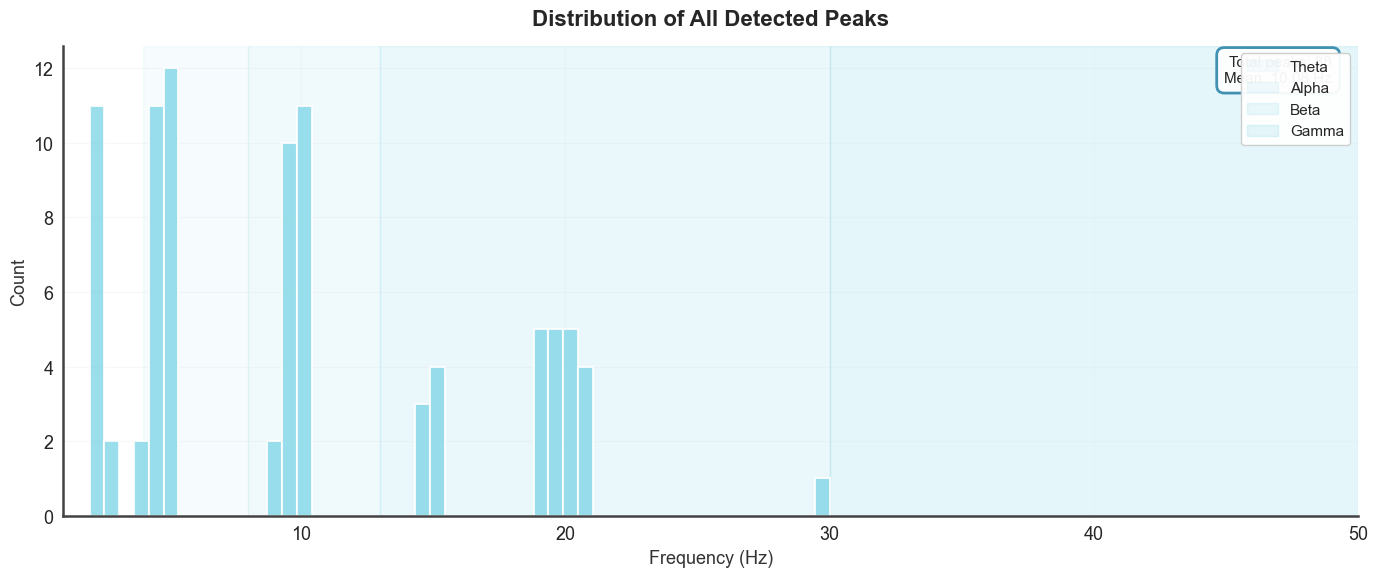

In [23]:
btg.plot_peak_distribution(xmin=1, xmax=50)
plt.show()

**Metric distributions split by condition.** Violin plots for several
harmonicity metrics, colored by the `condition` metadata column.

C:\Users\skite\Documents\Github\biotuner\biotuner\biotuner_group.py:1420: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=self.results, x=groupby, y=metric, ax=ax, palette=palette, **kwargs)


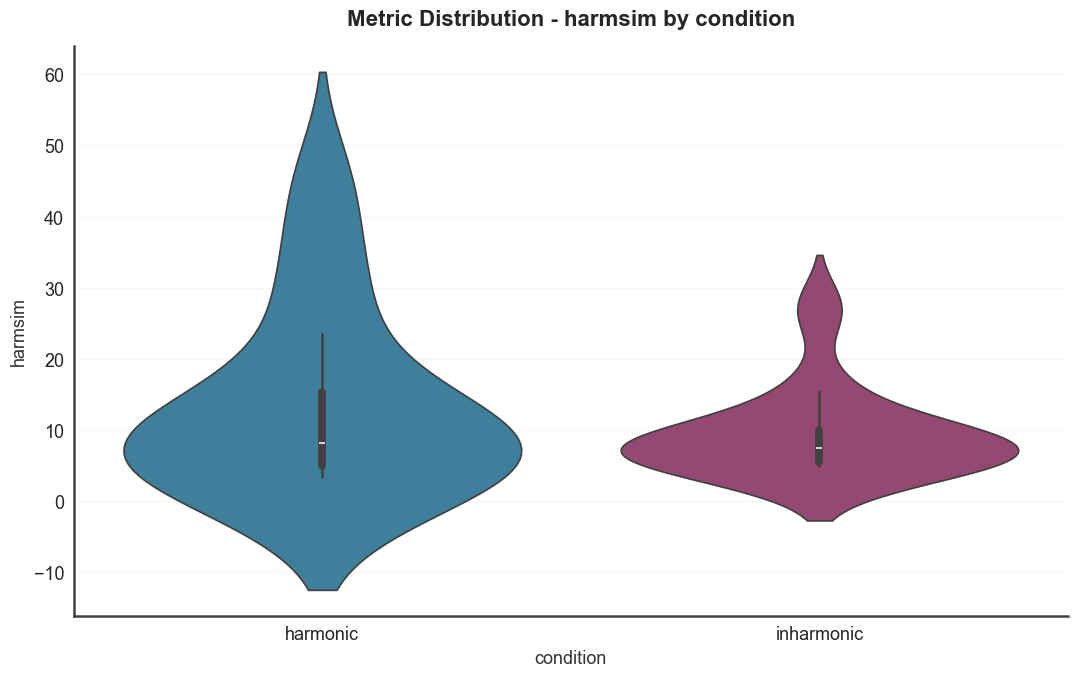

C:\Users\skite\Documents\Github\biotuner\biotuner\biotuner_group.py:1420: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=self.results, x=groupby, y=metric, ax=ax, palette=palette, **kwargs)


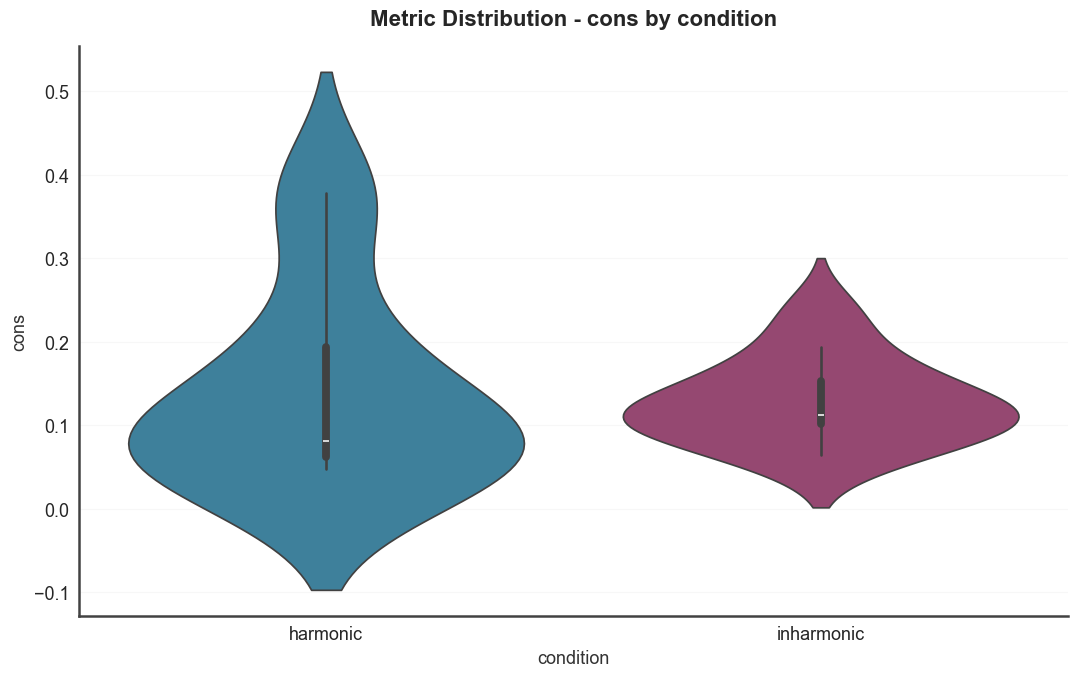

C:\Users\skite\Documents\Github\biotuner\biotuner\biotuner_group.py:1420: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=self.results, x=groupby, y=metric, ax=ax, palette=palette, **kwargs)


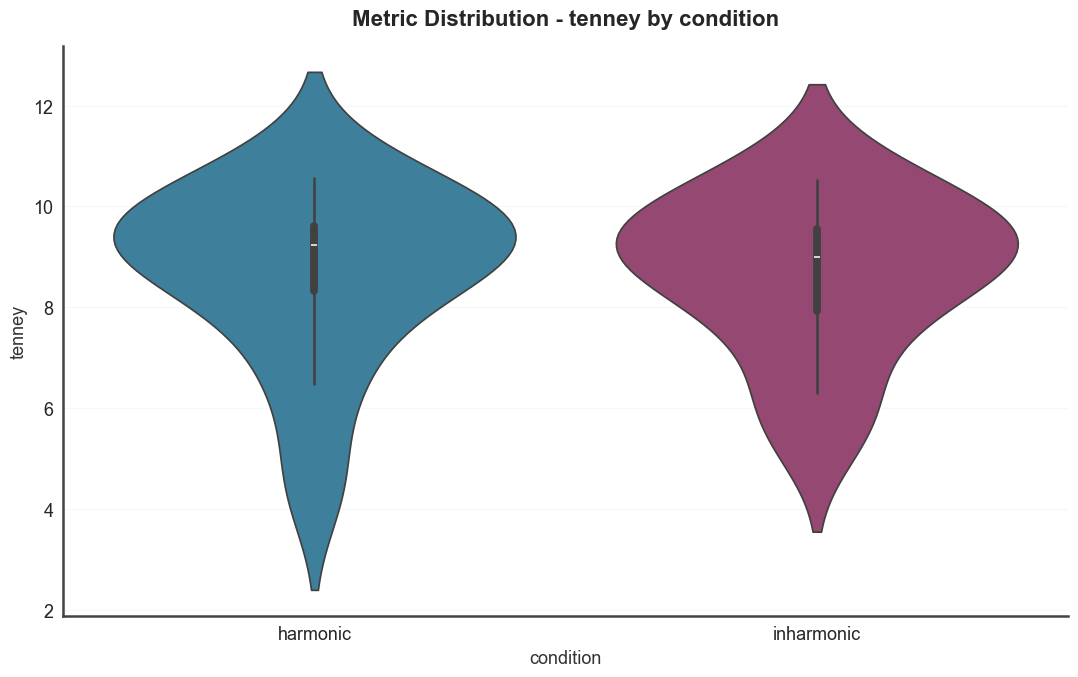

In [24]:
for metric in ["harmsim", "cons", "tenney"]:
    btg.plot_metric_distribution(metric, groupby="condition", kind="violin")
    plt.show()

**Interval histogram** across all derived scales — here using the
dissonance-curve scale. `show_common=True` overlays vertical lines at common
just-intonation ratios.

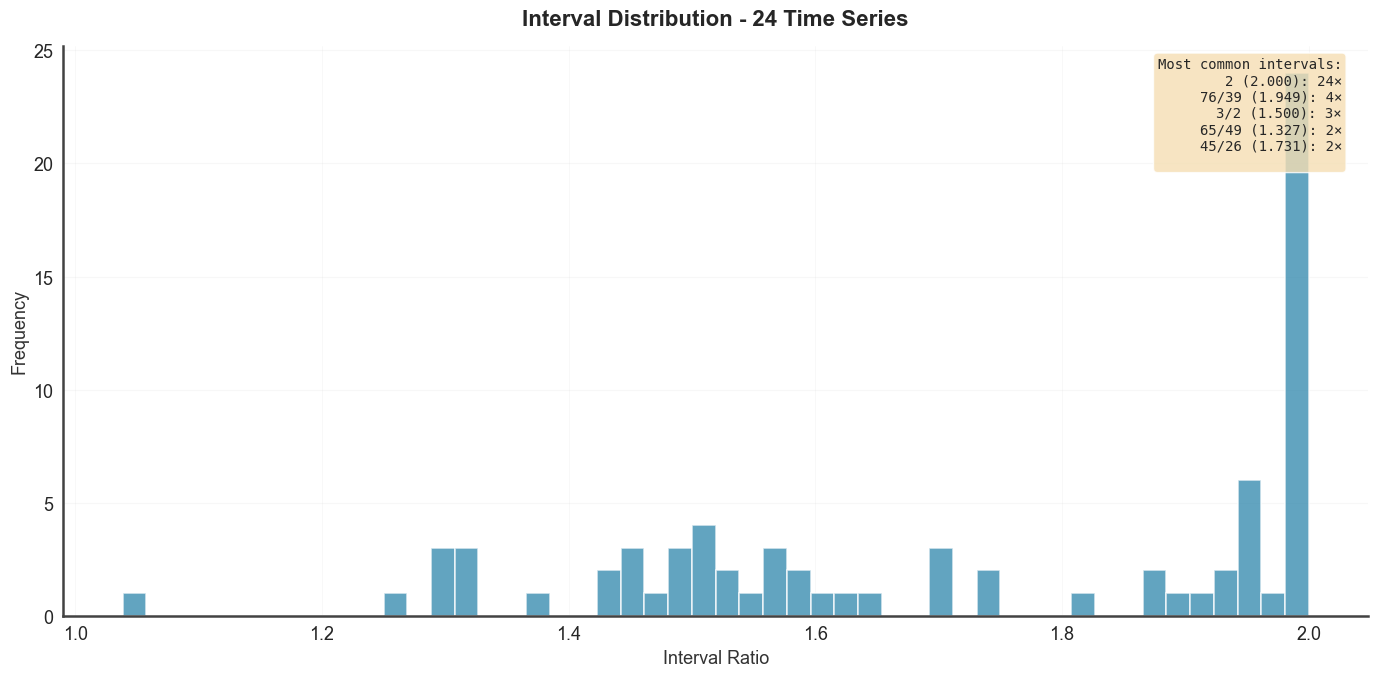

In [25]:
btg.plot_interval_histogram("diss_scale", show_common=True, max_denom=64)
plt.show()

**Distribution of scale sizes** (number of steps per scale).

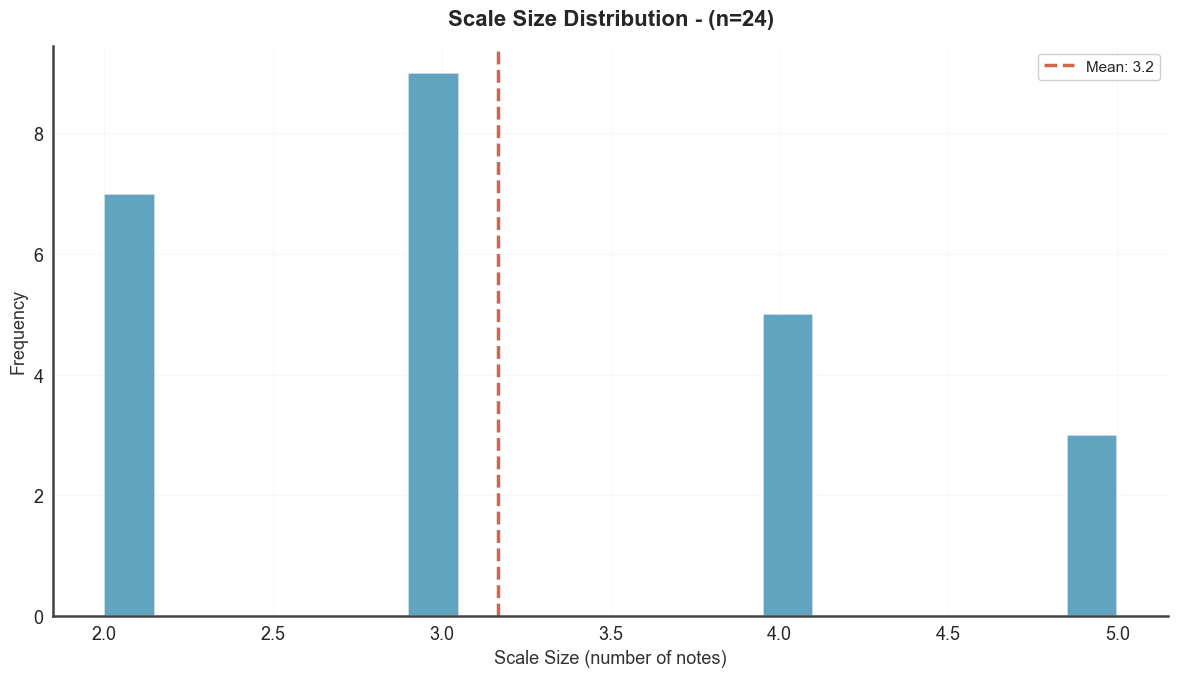

In [26]:
btg.plot_scale_size_distribution("diss_scale")
plt.show()

**Top 15 most frequent intervals** across the group.

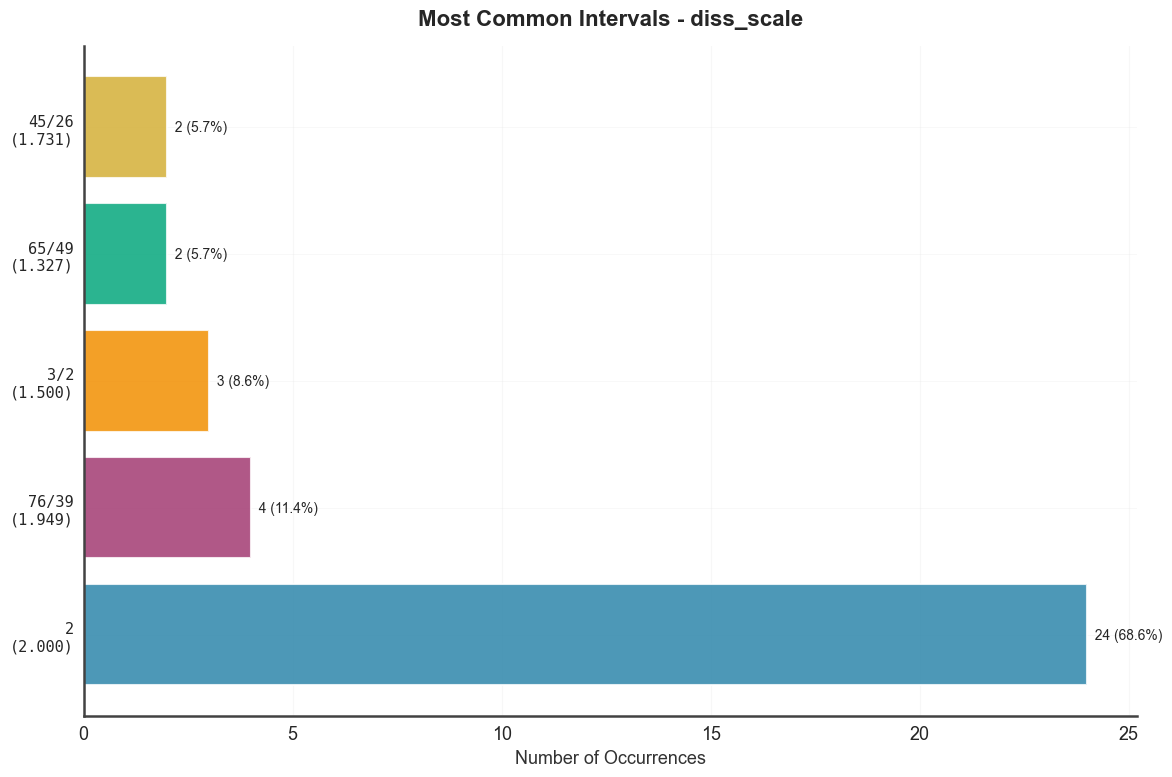

In [27]:
btg.plot_common_intervals("diss_scale", top_n=15)
plt.show()

**Side-by-side scale comparison** for a subset of trials — each row is
one trial's tuning, with steps drawn as vertical ticks on a log axis.

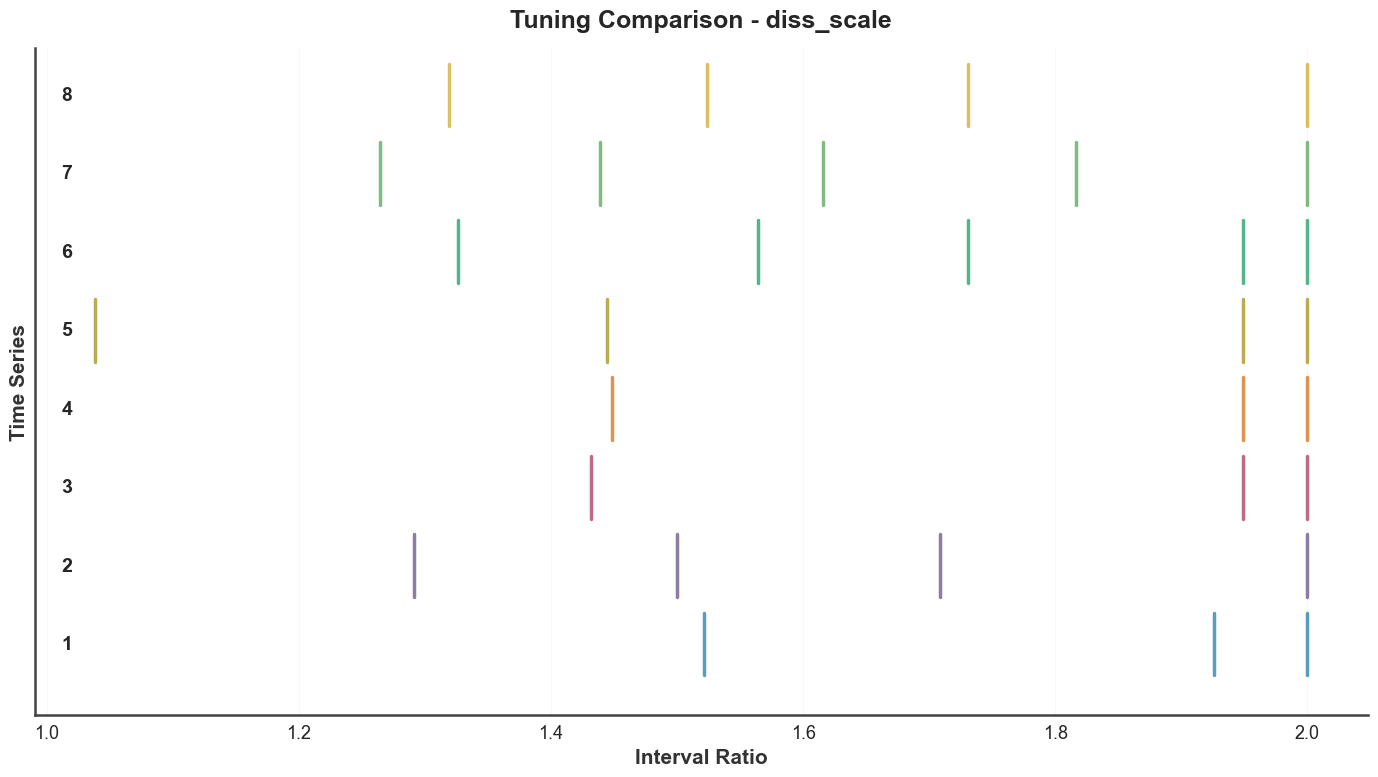

In [28]:
btg.plot_tuning_comparison("diss_scale", indices=list(range(8)))
plt.show()

### 7. 3D group heatmaps

When the input is 3D (`trials × channels × samples`), `BiotunerGroup`
exposes `plot_metric_matrix`, which renders metric values as a heatmap.

In [29]:
n_trials, n_ch = 8, 6
data_3d = np.array([
    [
        make_signal(
            [5 + rng.uniform(-0.5, 0.5),
             10 + rng.uniform(-0.5, 0.5),
             20 + rng.uniform(-1, 1)],
            [1.0, 0.7, 0.4],
            noise=0.1 + 0.05 * tr,
        )
        for _ in range(n_ch)
    ]
    for tr in range(n_trials)
])
print(f"3D data: {data_3d.shape}")

btg3 = BiotunerGroup(
    data_3d, sf=sf,
    axis_labels=["trial", "channel"],
    peaks_function="harmonic_recurrence",
    precision=0.25,
)
btg3.compute_peaks(min_freq=2, max_freq=50, n_peaks=5,
                   min_harms=2, verbose=False)
btg3.compute_metrics()
btg3.summary().head()

3D data: (8, 6, 8000)


C:\Users\skite\Documents\Github\biotuner\biotuner\metrics.py:946: RuntimeWarning: divide by zero encountered in scalar divide
  harm_temp.append(1 / delta_norm)


,trial,channel,series_idx,n_peaks,peak_freq_mean,peak_amp_mean,peak_freq_std,peak_amp_std,peak_freq_median,peak_amp_median,...,harm_pos_sem,subharm_tension,n_harmonic_recurrence,common_harm_pos,common_harm_pos_mean,common_harm_pos_std,common_harm_pos_median,common_harm_pos_min,common_harm_pos_max,common_harm_pos_sem
0,0,0,0,5,12.25,-26.493944,6.496153,21.793078,9.75,-42.435883,...,1.171771,0.019481,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,1,5,8.90,-26.447676,2.866182,21.615260,8.00,-43.653405,...,0.964203,0.014328,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2,2,5,13.35,-26.588977,14.084211,21.891383,8.25,-41.786047,...,1.030776,0.0,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3,3,5,8.95,-26.379970,3.508561,21.781310,8.50,-43.721270,...,1.030776,0.03544,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,4,4,5,9.35,-35.251479,5.791373,18.684407,8.00,-43.279380,...,1.006813,0.002496,27,5.0,NaN,NaN,NaN,NaN,NaN,NaN


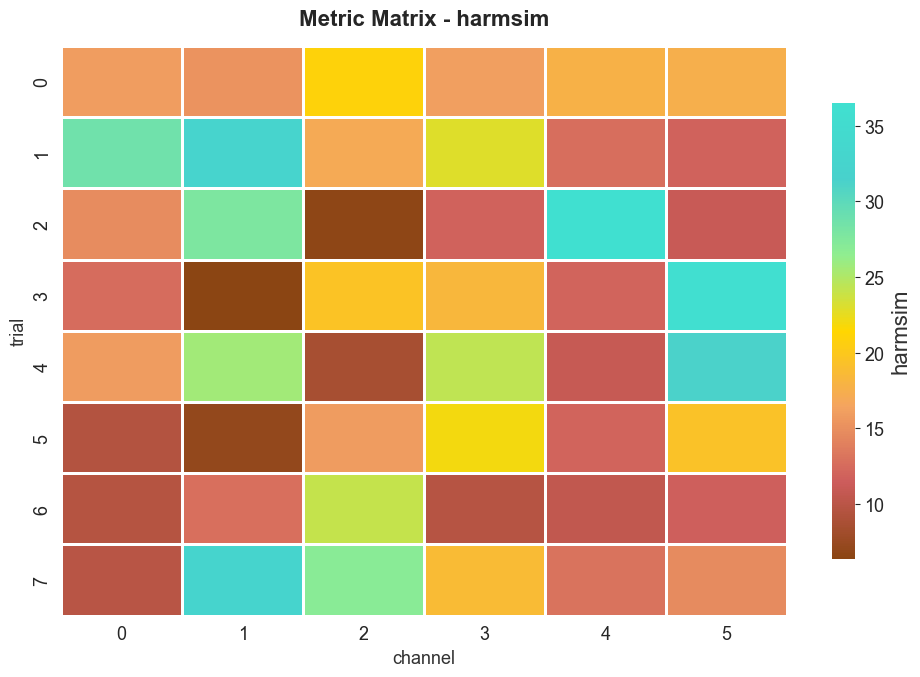

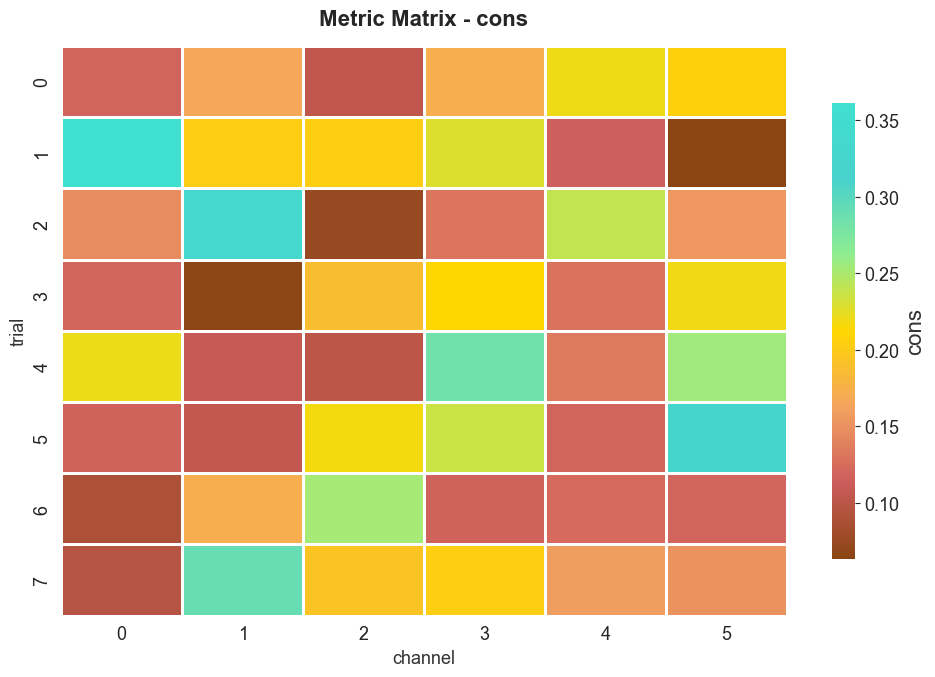

In [32]:
btg3.plot_metric_matrix(metric="harmsim")
plt.show()

btg3.plot_metric_matrix(metric="cons")
plt.show()

---

This walk-through covers the public plotting surface of biotuner. For the
underlying analysis (peak extraction, tuning derivation, dissonance curve
computation), see the [Peaks extraction](../peaks_extraction/peaks_extraction.ipynb),
[Scale construction](../scale_construction/scale_construction.ipynb), and
[BiotunerGroup](../../biotuner_group.md) docs.